In [ ]:
from google.colab import drive, userdata

drive.mount("/content/drive")
PROJECT_DIR = "/content/drive/MyDrive/NutriChat-RAG/NutriChat"
%cd "$PROJECT_DIR"

!pip install -qr requirements.txt



Mounted at /content/drive
/content/drive/MyDrive/NutriChat-RAG/NutriChat
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 85.2 MB/s eta 0:00:00


In [ ]:
!pip install -qe .

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for nutrichat (pyproject.toml) ... done


In [ ]:
from __future__ import annotations

import ast
import json
import math
import re
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
from openai import OpenAI

from nutrichat.chunking import (
    add_chunk_ids,
    add_sentences_to_pages,
    build_chunks,
    filter_chunks_by_min_tokens,
)
from nutrichat.config import (
    EMBEDDING_MODEL,
    GENERATION_MODEL,
    JUDGE_MODEL,
    MIN_TOKEN_LENGTH,
    PDF_PAGE_OFFSET,
    RERANKER_MODEL_NAME,
    ROUTER_MODEL,
    SystemSpec,
)
from nutrichat.data import (
    load_eval_questions,
    load_index_artifact,
    open_and_read_pdf,
    save_jsonl,
)
from nutrichat.embeddings import (
    embed_chunks,
    load_embedding_model,
)
from nutrichat.retrievers import (
    BM25Retriever,
    DenseRetriever,
    HybridRRFRetriever,
)

from nutrichat.evaluation import (
    run_system_evaluation_incremental,
)

from nutrichat.generation import (
    RAGPipeline,
)

from nutrichat.judging import (
    judge_dataframe_incremental,
)

from nutrichat.reranking import (
    load_reranker,
)

from nutrichat.safety import (
    SafetyRouter,
)


PROJECT_ROOT = Path.cwd()


PDF_PATH = PROJECT_ROOT / "data" / "nutrition_textbook.pdf"

DEV_DATASET_PATH = "data/eval_dataset_200_v2.json"

EXPERIMENT_ROOT = (
    PROJECT_ROOT
    / "results"
    / "chunking_selection"
)

ARTIFACT_ROOT = (
    PROJECT_ROOT
    / "artifacts"
    / "chunking_comparison"
)

EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)


STRATEGIES = [
    "sentence_15_no_overlap",
    "sentence_10_overlap_5",
    "sentence_8_overlap_4",
    "sentence_6_overlap_3",
    "word_180_overlap_40",
    "word_280_overlap_60",
]

RETRIEVER_NAMES = [
    "dense",
    "bm25",
    "hybrid_rrf",
]

CANDIDATE_DEPTHS = [10, 20, 30, 40]
MAX_CANDIDATE_K = max(CANDIDATE_DEPTHS)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)
print("PDF:", PDF_PATH)
print("Development dataset:", DEV_DATASET_PATH)

Device: cuda
PDF: /content/drive/MyDrive/NutriChat-RAG/NutriChat/data/nutrition_textbook.pdf
Development dataset: data/eval_dataset_200_v2.json


In [ ]:
dev_questions = load_eval_questions(
    DEV_DATASET_PATH
)

dev_answerable = [
    item
    for item in dev_questions
    if (
        item.get("expected_behavior") == "answer"
        and item.get("expected_pages")
    )
]

dev_nonanswerable = [
    item
    for item in dev_questions
    if item.get("expected_behavior") != "answer"
]

print("All development questions:", len(dev_questions))
print("Answerable development questions:", len(dev_answerable))
print("Non-answerable development questions:", len(dev_nonanswerable))

assert len(dev_questions) == 200
assert len(dev_answerable) == 140
assert len(dev_nonanswerable) == 60

All development questions: 200
Answerable development questions: 140
Non-answerable development questions: 60


In [ ]:
pages = open_and_read_pdf(
    PDF_PATH,
    page_offset=PDF_PAGE_OFFSET,
)

pages = add_sentences_to_pages(
    pages
)

embedding_model = load_embedding_model(
    model_name=EMBEDDING_MODEL,
    device=DEVICE,
)

print("Textbook pages:", len(pages))
print("Embedding model:", EMBEDDING_MODEL)

Reading PDF:   0%|          | 0/894 [00:00<?, ?it/s]

Sentence splitting:   0%|          | 0/894 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Textbook pages: 894
Embedding model: BAAI/bge-small-en-v1.5


In [ ]:
def build_or_load_strategy(
    strategy_name: str,
) -> tuple[list[dict], np.ndarray, dict]:
    strategy_dir = (
        ARTIFACT_ROOT
        / f"index_{strategy_name}"
    )

    chunks_path = (
        strategy_dir
        / "chunks.jsonl"
    )

    embeddings_path = (
        strategy_dir
        / "embeddings.npy"
    )

    manifest_path = (
        strategy_dir
        / "manifest.json"
    )

    strategy_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    if (
        chunks_path.exists()
        and embeddings_path.exists()
    ):
        print(
            f"Loading existing artifact: "
            f"{strategy_name}"
        )

        chunks, embeddings_np = (
            load_index_artifact(
                strategy_dir
            )
        )

        build_seconds = None

    else:
        print(
            f"Building artifact: "
            f"{strategy_name}"
        )

        start_build = perf_counter()

        chunks = build_chunks(
            pages=pages,
            strategy_name=strategy_name,
        )

        chunks = filter_chunks_by_min_tokens(
            chunks=chunks,
            min_token_length=MIN_TOKEN_LENGTH,
        )

        chunks = add_chunk_ids(
            chunks
        )

        embeddings_np = embed_chunks(
            chunks=chunks,
            model=embedding_model,
            batch_size=64,
            show_progress_bar=True,
        )

        save_jsonl(
            chunks,
            chunks_path,
        )

        np.save(
            embeddings_path,
            embeddings_np,
            allow_pickle=False,
        )

        build_seconds = (
            perf_counter()
            - start_build
        )

    chunk_token_counts = np.array(
        [
            float(
                chunk.get(
                    "chunk_token_count",
                    len(
                        chunk["sentence_chunk"]
                    ) / 4,
                )
            )
            for chunk in chunks
        ],
        dtype=float,
    )

    stats = {
        "strategy": strategy_name,
        "n_chunks": len(chunks),
        "mean_chunk_tokens": float(
            chunk_token_counts.mean()
        ),
        "median_chunk_tokens": float(
            np.median(
                chunk_token_counts
            )
        ),
        "p95_chunk_tokens": float(
            np.quantile(
                chunk_token_counts,
                0.95,
            )
        ),
        "embeddings_mb": (
            embeddings_path.stat().st_size
            / (1024 ** 2)
        ),
        "chunks_file_mb": (
            chunks_path.stat().st_size
            / (1024 ** 2)
        ),
        "total_artifact_mb": (
            (
                embeddings_path.stat().st_size
                + chunks_path.stat().st_size
            )
            / (1024 ** 2)
        ),
        "build_seconds": build_seconds,
    }

    manifest_path.write_text(
        json.dumps(
            {
                **stats,
                "embedding_model": EMBEDDING_MODEL,
                "minimum_token_length": MIN_TOKEN_LENGTH,
            },
            indent=2,
        ),
        encoding="utf-8",
    )

    return (
        chunks,
        embeddings_np,
        stats,
    )

In [ ]:
strategy_artifacts = {}
index_stat_rows = []

for strategy_name in STRATEGIES:
    chunks, embeddings_np, stats = (
        build_or_load_strategy(
            strategy_name
        )
    )

    strategy_artifacts[
        strategy_name
    ] = {
        "chunks": chunks,
        "embeddings": embeddings_np,
    }

    index_stat_rows.append(
        stats
    )

index_stats = pd.DataFrame(
    index_stat_rows
).sort_values(
    "n_chunks"
)

display(index_stats)

index_stats.to_csv(
    EXPERIMENT_ROOT
    / "index_statistics.csv",
    index=False,
)

Loading existing artifact: sentence_15_no_overlap
Loading existing artifact: sentence_10_overlap_5
Loading existing artifact: sentence_8_overlap_4
Loading existing artifact: sentence_6_overlap_3
Loading existing artifact: word_180_overlap_40
Loading existing artifact: word_280_overlap_60


,strategy,n_chunks,mean_chunk_tokens,median_chunk_tokens,p95_chunk_tokens,embeddings_mb,chunks_file_mb,total_artifact_mb,build_seconds
0,sentence_15_no_overlap,1212,276.644596,275.250,530.3625,1.775513,2.846930,4.622442,None
5,word_280_overlap_60,1309,289.385791,313.750,469.6500,1.917603,3.199024,5.116627,None
4,word_180_overlap_40,1800,221.428889,263.500,314.0000,2.636841,3.461678,6.098518,None
1,sentence_10_overlap_5,2684,200.045082,202.375,382.2500,3.931763,4.725944,8.657706,None
2,sentence_8_overlap_4,3258,171.105893,173.125,318.7500,4.772583,5.010350,9.782933,None
3,sentence_6_overlap_3,4192,137.979902,139.750,255.2500,6.140747,5.381269,11.522016,None


In [ ]:
def normalize_page(
    value,
) -> int | None:
    try:
        return int(value)
    except (TypeError, ValueError):
        return None


def normalized_page_set(
    pages,
) -> set[int]:
    return {
        page
        for value in pages
        if (
            page := normalize_page(value)
        ) is not None
    }


def retrieved_pages_from_items(
    items: list[dict],
    k: int,
) -> list[int]:
    output = []

    for item in items[:k]:
        page = normalize_page(
            item.get("page_number")
        )

        if page is not None:
            output.append(page)

    return output


def page_hit_at_k(
    items: list[dict],
    expected_pages,
    k: int,
) -> float:
    expected = normalized_page_set(
        expected_pages
    )

    if not expected:
        return float("nan")

    retrieved = set(
        retrieved_pages_from_items(
            items,
            k,
        )
    )

    return float(
        bool(
            expected.intersection(
                retrieved
            )
        )
    )


def expected_page_recall_at_k(
    items: list[dict],
    expected_pages,
    k: int,
) -> float:
    expected = normalized_page_set(
        expected_pages
    )

    if not expected:
        return float("nan")

    retrieved = set(
        retrieved_pages_from_items(
            items,
            k,
        )
    )

    return (
        len(
            expected.intersection(
                retrieved
            )
        )
        / len(expected)
    )


def all_expected_pages_at_k(
    items: list[dict],
    expected_pages,
    k: int,
) -> float:
    expected = normalized_page_set(
        expected_pages
    )

    if not expected:
        return float("nan")

    retrieved = set(
        retrieved_pages_from_items(
            items,
            k,
        )
    )

    return float(
        expected.issubset(
            retrieved
        )
    )


def reciprocal_rank_at_k(
    items: list[dict],
    expected_pages,
    k: int,
) -> float:
    expected = normalized_page_set(
        expected_pages
    )

    if not expected:
        return float("nan")

    for rank, item in enumerate(
        items[:k],
        start=1,
    ):
        page = normalize_page(
            item.get("page_number")
        )

        if page in expected:
            return 1.0 / rank

    return 0.0


def unique_pages_at_k(
    items: list[dict],
    k: int,
) -> int:
    return len(
        set(
            retrieved_pages_from_items(
                items,
                k,
            )
        )
    )


def same_page_redundancy_at_k(
    items: list[dict],
    k: int,
) -> int:
    pages = retrieved_pages_from_items(
        items,
        k,
    )

    return (
        len(pages)
        - len(set(pages))
    )


def normalize_text(
    text: str,
) -> str:
    return re.sub(
        r"\s+",
        " ",
        str(text).lower(),
    ).strip()


def token_set(
    text: str,
) -> set[str]:
    return set(
        re.findall(
            r"[a-z0-9]+",
            str(text).lower(),
        )
    )


def token_overlap_coefficient(
    text_a: str,
    text_b: str,
) -> float:
    tokens_a = token_set(text_a)
    tokens_b = token_set(text_b)

    if not tokens_a or not tokens_b:
        return 0.0

    return (
        len(
            tokens_a.intersection(
                tokens_b
            )
        )
        / min(
            len(tokens_a),
            len(tokens_b),
        )
    )


def chunk_redundancy_stats(
    items: list[dict],
    k: int,
    overlap_threshold: float = 0.50,
) -> dict:
    selected = items[:k]

    texts = [
        str(
            item.get(
                "sentence_chunk",
                "",
            )
        )
        for item in selected
    ]

    exact_duplicate_count = (
        len(texts)
        - len(
            {
                normalize_text(text)
                for text in texts
            }
        )
    )

    overlap_values = []

    for left_index in range(
        len(texts)
    ):
        for right_index in range(
            left_index + 1,
            len(texts),
        ):
            overlap_values.append(
                token_overlap_coefficient(
                    texts[left_index],
                    texts[right_index],
                )
            )

    overlapping_pair_count = sum(
        value >= overlap_threshold
        for value in overlap_values
    )

    mean_pairwise_overlap = (
        float(
            np.mean(
                overlap_values
            )
        )
        if overlap_values
        else 0.0
    )

    return {
        "exact_duplicate_count": (
            exact_duplicate_count
        ),
        "overlapping_pair_count": (
            overlapping_pair_count
        ),
        "mean_pairwise_overlap": (
            mean_pairwise_overlap
        ),
    }


def estimated_context_tokens_at_k(
    items: list[dict],
    k: int,
) -> float:
    return float(
        sum(
            float(
                item.get(
                    "chunk_token_count",
                    len(
                        item.get(
                            "sentence_chunk",
                            "",
                        )
                    ) / 4,
                )
            )
            for item in items[:k]
        )
    )

In [ ]:
def build_retrievers_for_strategy(
    chunks: list[dict],
    embeddings_np: np.ndarray,
) -> dict:
    embeddings_tensor = (
        torch.from_numpy(
            embeddings_np
        )
        .to(
            dtype=torch.float32,
            device=DEVICE,
        )
    )

    dense_retriever = DenseRetriever(
        chunks=chunks,
        embeddings=embeddings_tensor,
        embedding_model=embedding_model,
    )

    bm25_retriever = BM25Retriever(
        chunks=chunks,
    )

    hybrid_retriever = (
        HybridRRFRetriever(
            dense_retriever=dense_retriever,
            bm25_retriever=bm25_retriever,
        )
    )

    return {
        "dense": dense_retriever,
        "bm25": bm25_retriever,
        "hybrid_rrf": hybrid_retriever,
    }


strategy_retrievers = {}

for strategy_name in STRATEGIES:
    artifact = strategy_artifacts[
        strategy_name
    ]

    strategy_retrievers[
        strategy_name
    ] = build_retrievers_for_strategy(
        chunks=artifact["chunks"],
        embeddings_np=artifact["embeddings"],
    )

In [ ]:
def synchronize_device() -> None:
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def retrieve_with_wall_time(
    retriever,
    query: str,
    candidate_k: int,
):
    synchronize_device()

    start = perf_counter()

    output = retriever.retrieve(
        query=query,
        candidate_k=candidate_k,
        final_k=candidate_k,
        use_reranker=False,
        reranker_model=None,
    )

    synchronize_device()

    wall_seconds = (
        perf_counter()
        - start
    )

    return output, wall_seconds

In [ ]:
def get_retrival_rows():
  retrieval_rows = []

  for strategy_name in STRATEGIES:
      print(
          "\n" + "=" * 70
      )
      print(
          "Strategy:",
          strategy_name,
      )
      print(
          "=" * 70
      )

      retrievers = strategy_retrievers[
          strategy_name
      ]

      strategy_stats = (
          index_stats
          .set_index("strategy")
          .loc[strategy_name]
      )

      for retriever_name in RETRIEVER_NAMES:
          print(
              "Retriever:",
              retriever_name,
          )

          retriever = retrievers[
              retriever_name
          ]

          # Small warm-up outside timing summaries.
          for warm_item in dev_answerable[:3]:
              retriever.retrieve(
                  query=warm_item["question"],
                  candidate_k=20,
                  final_k=20,
                  use_reranker=False,
                  reranker_model=None,
              )

          for item in dev_answerable:
              expected_pages = item[
                  "expected_pages"
              ]

              for candidate_k in CANDIDATE_DEPTHS:
                  output, wall_seconds = (
                      retrieve_with_wall_time(
                          retriever=retriever,
                          query=item["question"],
                          candidate_k=candidate_k,
                      )
                  )

                  retrieved_items = (
                      output.context_items
                  )

                  row = {
                      "strategy": strategy_name,
                      "retriever": retriever_name,
                      "candidate_k": candidate_k,
                      "id": item["id"],
                      "question": item["question"],
                      "category": item.get(
                          "category"
                      ),
                      "question_type": item.get(
                          "question_type"
                      ),
                      "difficulty": item.get(
                          "difficulty"
                      ),
                      "expected_pages": (
                          expected_pages
                      ),
                      "n_chunks": int(
                          strategy_stats[
                              "n_chunks"
                          ]
                      ),
                      "mean_chunk_tokens": float(
                          strategy_stats[
                              "mean_chunk_tokens"
                          ]
                      ),
                      "total_artifact_mb": float(
                          strategy_stats[
                              "total_artifact_mb"
                          ]
                      ),
                      "wall_retrieval_seconds": (
                          wall_seconds
                      ),
                      "internal_retrieval_seconds": (
                          output
                          .retrieval_total_seconds
                      ),
                      "retrieved_pages": [
                          item.get(
                              "page_number"
                          )
                          for item in retrieved_items
                      ],
                      "retrieved_chunk_ids": [
                          item.get(
                              "chunk_id"
                          )
                          for item in retrieved_items
                      ],
                  }

                  for metric_k in [
                      1,
                      3,
                      5,
                      10,
                      20,
                      30,
                      40,
                  ]:
                      if metric_k > candidate_k:
                          continue

                      row[
                          f"page_hit_at_{metric_k}"
                      ] = page_hit_at_k(
                          retrieved_items,
                          expected_pages,
                          metric_k,
                      )

                      row[
                          f"page_recall_at_{metric_k}"
                      ] = (
                          expected_page_recall_at_k(
                              retrieved_items,
                              expected_pages,
                              metric_k,
                          )
                      )

                      row[
                          f"all_pages_at_{metric_k}"
                      ] = (
                          all_expected_pages_at_k(
                              retrieved_items,
                              expected_pages,
                              metric_k,
                          )
                      )

                      row[
                          f"mrr_at_{metric_k}"
                      ] = reciprocal_rank_at_k(
                          retrieved_items,
                          expected_pages,
                          metric_k,
                      )

                      row[
                          f"unique_pages_at_{metric_k}"
                      ] = unique_pages_at_k(
                          retrieved_items,
                          metric_k,
                      )

                      row[
                          f"same_page_redundancy_at_{metric_k}"
                      ] = (
                          same_page_redundancy_at_k(
                              retrieved_items,
                              metric_k,
                          )
                      )

                      redundancy = (
                          chunk_redundancy_stats(
                              retrieved_items,
                              metric_k,
                          )
                      )

                      row[
                          f"overlap_pairs_at_{metric_k}"
                      ] = redundancy[
                          "overlapping_pair_count"
                      ]

                      row[
                          f"mean_pairwise_overlap_at_{metric_k}"
                      ] = redundancy[
                          "mean_pairwise_overlap"
                      ]

                      row[
                          f"context_tokens_at_{metric_k}"
                      ] = (
                          estimated_context_tokens_at_k(
                              retrieved_items,
                              metric_k,
                          )
                      )

                  # Metric at the complete candidate pool.
                  row[
                      "candidate_any_hit"
                  ] = page_hit_at_k(
                      retrieved_items,
                      expected_pages,
                      candidate_k,
                  )

                  row[
                      "candidate_page_recall"
                  ] = (
                      expected_page_recall_at_k(
                          retrieved_items,
                          expected_pages,
                          candidate_k,
                      )
                  )

                  row[
                      "candidate_all_pages"
                  ] = (
                      all_expected_pages_at_k(
                          retrieved_items,
                          expected_pages,
                          candidate_k,
                      )
                  )

                  row[
                      "candidate_mrr"
                  ] = reciprocal_rank_at_k(
                      retrieved_items,
                      expected_pages,
                      candidate_k,
                  )

                  retrieval_rows.append(
                      row
                  )
  return retrieval_rows



In [ ]:
def save_retrival_detail():
  retrieval_rows = get_retrival_rows()
  retrieval_detail = pd.DataFrame(
    retrieval_rows
)

  retrieval_detail.to_pickle(
      EXPERIMENT_ROOT
      / "retrieval_detail.pkl"
  )

  retrieval_detail.to_csv(
      EXPERIMENT_ROOT
      / "retrieval_detail.csv",
      index=False,
  )

  print(
      "Retrieval rows:",
      len(retrieval_detail),
  )

In [ ]:
from pathlib import Path

import pandas as pd


pickle_path = (
    EXPERIMENT_ROOT
    / "retrieval_detail.pkl"
)

if not pickle_path.exists():
    save_retrival_detail()

retrieval_detail = pd.read_pickle(
    pickle_path
)

print("Loaded file:", pickle_path)
print("Retrieval rows:", len(retrieval_detail))
print("Shape:", retrieval_detail.shape)

display(
    retrieval_detail.head()
)

Loaded file: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/retrieval_detail.pkl
Retrieval rows: 10080
Shape: (10080, 83)


,strategy,retriever,candidate_k,id,question,category,question_type,difficulty,expected_pages,n_chunks,...,context_tokens_at_30,page_hit_at_40,page_recall_at_40,all_pages_at_40,mrr_at_40,unique_pages_at_40,same_page_redundancy_at_40,overlap_pairs_at_40,mean_pairwise_overlap_at_40,context_tokens_at_40
0,sentence_15_no_overlap,dense,10,A001,Which six classes of nutrients are required fo...,basic_concepts,factual,easy,[4],1212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sentence_15_no_overlap,dense,20,A001,Which six classes of nutrients are required fo...,basic_concepts,factual,easy,[4],1212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sentence_15_no_overlap,dense,30,A001,Which six classes of nutrients are required fo...,basic_concepts,factual,easy,[4],1212,...,9939.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sentence_15_no_overlap,dense,40,A001,Which six classes of nutrients are required fo...,basic_concepts,factual,easy,[4],1212,...,9939.75,1.0,1.0,1.0,1.0,39.0,1.0,9.0,0.248612,12728.0
4,sentence_15_no_overlap,dense,10,A002,What is a macronutrient?,basic_concepts,definition,easy,[5],1212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
candidate_depth_summary = (
    retrieval_detail
    .groupby(
        [
            "strategy",
            "retriever",
            "candidate_k",
        ],
        as_index=False,
    )
    .agg(
        n_questions=(
            "id",
            "count",
        ),
        any_expected_page_rate=(
            "candidate_any_hit",
            "mean",
        ),
        mean_expected_page_recall=(
            "candidate_page_recall",
            "mean",
        ),
        all_expected_pages_rate=(
            "candidate_all_pages",
            "mean",
        ),
        mean_mrr=(
            "candidate_mrr",
            "mean",
        ),
        mean_retrieval_seconds=(
            "wall_retrieval_seconds",
            "mean",
        ),
        median_retrieval_seconds=(
            "wall_retrieval_seconds",
            "median",
        ),
    )
)

display(
    candidate_depth_summary
)

candidate_depth_summary.to_csv(
    EXPERIMENT_ROOT
    / "candidate_depth_summary.csv",
    index=False,
)

,strategy,retriever,candidate_k,n_questions,any_expected_page_rate,mean_expected_page_recall,all_expected_pages_rate,mean_mrr,mean_retrieval_seconds,median_retrieval_seconds
0,sentence_10_overlap_5,bm25,10,140,0.935714,0.897024,0.857143,0.767588,0.010766,0.010575
1,sentence_10_overlap_5,bm25,20,140,0.957143,0.932738,0.907143,0.769090,0.008928,0.008511
2,sentence_10_overlap_5,bm25,30,140,0.978571,0.964881,0.950000,0.770050,0.009392,0.008726
3,sentence_10_overlap_5,bm25,40,140,0.978571,0.964881,0.950000,0.770050,0.010394,0.009626
4,sentence_10_overlap_5,dense,10,140,0.978571,0.964286,0.950000,0.890306,0.013127,0.011780
...,...,...,...,...,...,...,...,...,...,...
67,word_280_overlap_60,dense,40,140,1.000000,1.000000,1.000000,0.855227,0.014417,0.013033
68,word_280_overlap_60,hybrid_rrf,10,140,1.000000,0.989286,0.978571,0.866814,0.018948,0.017525
69,word_280_overlap_60,hybrid_rrf,20,140,1.000000,0.994643,0.985714,0.862435,0.018571,0.016503
70,word_280_overlap_60,hybrid_rrf,30,140,1.000000,0.996429,0.992857,0.860054,0.019670,0.017567


In [ ]:
hybrid_candidate_depth = (
    candidate_depth_summary[
        candidate_depth_summary[
            "retriever"
        ] == "hybrid_rrf"
    ]
    .sort_values(
        [
            "strategy",
            "candidate_k",
        ]
    )
)

display(
    hybrid_candidate_depth
)

,strategy,retriever,candidate_k,n_questions,any_expected_page_rate,mean_expected_page_recall,all_expected_pages_rate,mean_mrr,mean_retrieval_seconds,median_retrieval_seconds
8,sentence_10_overlap_5,hybrid_rrf,10,140,0.985714,0.966071,0.950000,0.870476,0.025362,0.023251
9,sentence_10_overlap_5,hybrid_rrf,20,140,0.992857,0.985714,0.978571,0.864702,0.024109,0.020929
10,sentence_10_overlap_5,hybrid_rrf,30,140,1.000000,0.996429,0.992857,0.864559,0.025491,0.021935
11,sentence_10_overlap_5,hybrid_rrf,40,140,1.000000,1.000000,1.000000,0.862576,0.025434,0.022934
20,sentence_15_no_overlap,hybrid_rrf,10,140,1.000000,0.994643,0.985714,0.879762,0.018920,0.017258
21,sentence_15_no_overlap,hybrid_rrf,20,140,1.000000,1.000000,1.000000,0.874702,0.018246,0.016146
22,sentence_15_no_overlap,hybrid_rrf,30,140,1.000000,1.000000,1.000000,0.871825,0.018483,0.016926
23,sentence_15_no_overlap,hybrid_rrf,40,140,1.000000,1.000000,1.000000,0.870634,0.020049,0.017770
32,sentence_6_overlap_3,hybrid_rrf,10,140,0.985714,0.969643,0.957143,0.902211,0.030049,0.027706
33,sentence_6_overlap_3,hybrid_rrf,20,140,0.992857,0.983929,0.971429,0.884076,0.027796,0.026218


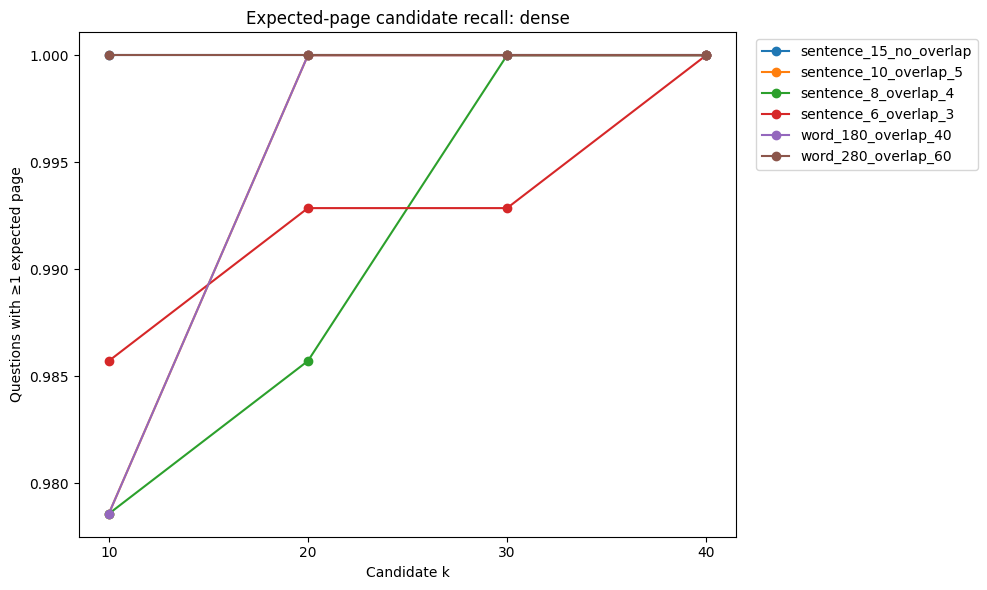

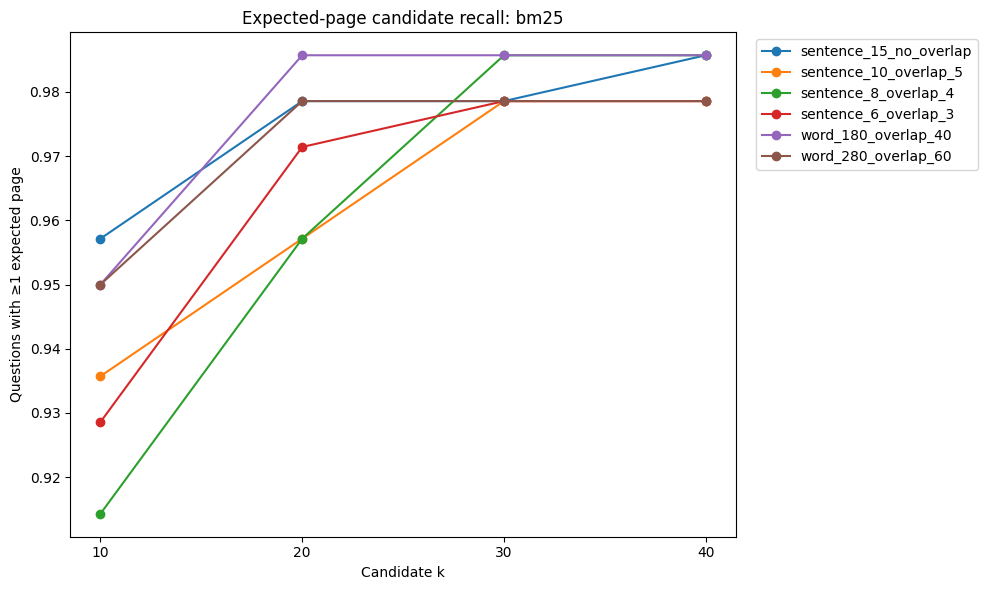

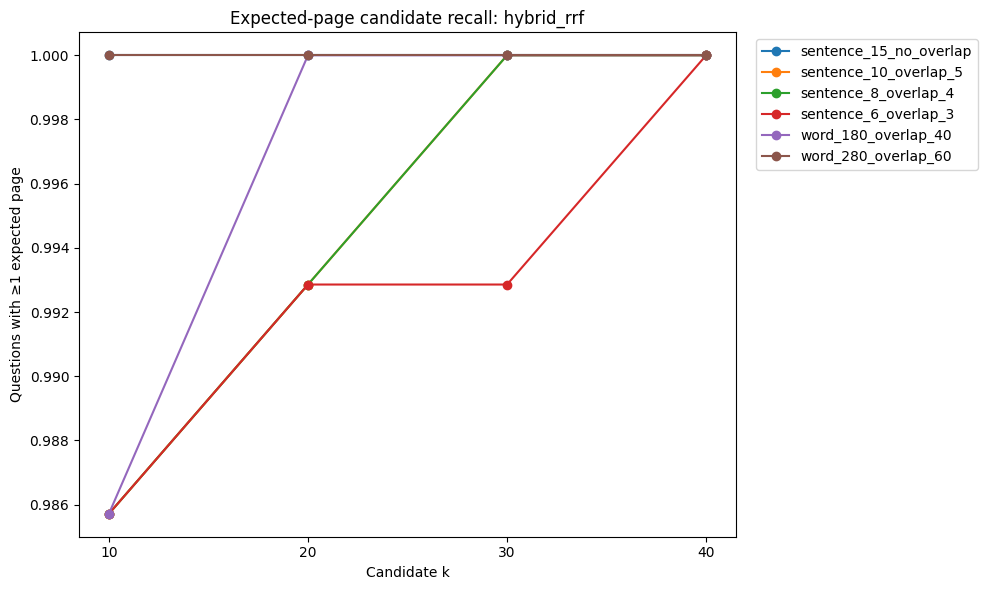

In [ ]:
import matplotlib.pyplot as plt


for retriever_name in RETRIEVER_NAMES:
    plot_df = (
        candidate_depth_summary[
            candidate_depth_summary[
                "retriever"
            ] == retriever_name
        ]
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    for strategy_name in STRATEGIES:
        strategy_df = (
            plot_df[
                plot_df[
                    "strategy"
                ] == strategy_name
            ]
            .sort_values(
                "candidate_k"
            )
        )

        ax.plot(
            strategy_df["candidate_k"],
            strategy_df[
                "any_expected_page_rate"
            ],
            marker="o",
            label=strategy_name,
        )

    ax.set_title(
        f"Expected-page candidate recall: "
        f"{retriever_name}"
    )
    ax.set_xlabel(
        "Candidate k"
    )
    ax.set_ylabel(
        "Questions with ≥1 expected page"
    )
    ax.set_xticks(
        CANDIDATE_DEPTHS
    )
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    fig.tight_layout()
    plt.show()

In [ ]:
ranking_runs = retrieval_detail[
    retrieval_detail[
        "candidate_k"
    ] == 40
].copy()


stage1_summary = (
    ranking_runs
    .groupby(
        [
            "strategy",
            "retriever",
        ],
        as_index=False,
    )
    .agg(
        n_questions=(
            "id",
            "count",
        ),

        page_hit_at_1=(
            "page_hit_at_1",
            "mean",
        ),
        page_hit_at_3=(
            "page_hit_at_3",
            "mean",
        ),
        page_hit_at_5=(
            "page_hit_at_5",
            "mean",
        ),

        page_recall_at_20=(
            "page_recall_at_20",
            "mean",
        ),
        all_pages_at_20=(
            "all_pages_at_20",
            "mean",
        ),

        mrr_at_3=(
            "mrr_at_3",
            "mean",
        ),
        mrr_at_40=(
            "mrr_at_40",
            "mean",
        ),

        mean_unique_pages_at_3=(
            "unique_pages_at_3",
            "mean",
        ),
        mean_same_page_redundancy_at_3=(
            "same_page_redundancy_at_3",
            "mean",
        ),
        mean_overlap_pairs_at_3=(
            "overlap_pairs_at_3",
            "mean",
        ),
        mean_pairwise_overlap_at_3=(
            "mean_pairwise_overlap_at_3",
            "mean",
        ),

        mean_context_tokens_at_3=(
            "context_tokens_at_3",
            "mean",
        ),

        mean_retrieval_seconds=(
            "wall_retrieval_seconds",
            "mean",
        ),
        median_retrieval_seconds=(
            "wall_retrieval_seconds",
            "median",
        ),

        n_chunks=(
            "n_chunks",
            "first",
        ),
        total_artifact_mb=(
            "total_artifact_mb",
            "first",
        ),
    )
)

display(
    stage1_summary.sort_values(
        [
            "retriever",
            "page_hit_at_3",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

stage1_summary.to_csv(
    EXPERIMENT_ROOT
    / "stage1_summary.csv",
    index=False,
)

,strategy,retriever,n_questions,page_hit_at_1,page_hit_at_3,page_hit_at_5,page_recall_at_20,all_pages_at_20,mrr_at_3,mrr_at_40,mean_unique_pages_at_3,mean_same_page_redundancy_at_3,mean_overlap_pairs_at_3,mean_pairwise_overlap_at_3,mean_context_tokens_at_3,mean_retrieval_seconds,median_retrieval_seconds,n_chunks,total_artifact_mb
3,sentence_15_no_overlap,bm25,140,0.671429,0.864286,0.928571,0.961310,0.942857,0.755952,0.776363,2.928571,0.071429,0.042857,0.289869,1119.489286,0.005099,0.004685,1212,4.622442
12,word_180_overlap_40,bm25,140,0.700000,0.864286,0.921429,0.961310,0.935714,0.776190,0.796188,2.678571,0.321429,0.207143,0.301367,767.933929,0.006908,0.006456,1800,6.098518
15,word_280_overlap_60,bm25,140,0.700000,0.864286,0.921429,0.963690,0.942857,0.770238,0.789306,2.821429,0.178571,0.142857,0.304402,1105.010714,0.005671,0.005434,1309,5.116627
9,sentence_8_overlap_4,bm25,140,0.700000,0.857143,0.878571,0.930952,0.907143,0.770238,0.784262,2.235714,0.764286,0.750000,0.393209,666.116071,0.011675,0.010999,3258,9.782933
0,sentence_10_overlap_5,bm25,140,0.678571,0.828571,0.878571,0.932738,0.907143,0.746429,0.770050,2.292857,0.707143,0.714286,0.397781,778.937500,0.010394,0.009626,2684,8.657706
6,sentence_6_overlap_3,bm25,140,0.664286,0.814286,0.864286,0.947024,0.921429,0.729762,0.753447,2.150000,0.850000,0.828571,0.402581,516.314286,0.015213,0.014409,4192,11.522016
7,sentence_6_overlap_3,dense,140,0.864286,0.950000,0.971429,0.985714,0.978571,0.902381,0.909801,2.028571,0.971429,0.921429,0.417002,521.935714,0.014684,0.012377,4192,11.522016
13,word_180_overlap_40,dense,140,0.785714,0.950000,0.964286,1.000000,1.000000,0.861905,0.868123,2.471429,0.528571,0.357143,0.332111,752.596429,0.014416,0.012658,1800,6.098518
10,sentence_8_overlap_4,dense,140,0.842857,0.942857,0.971429,0.978571,0.971429,0.885714,0.894331,2.135714,0.864286,0.800000,0.414670,664.307143,0.013494,0.012326,3258,9.782933
1,sentence_10_overlap_5,dense,140,0.842857,0.928571,0.957143,0.992857,0.985714,0.879762,0.892015,2.135714,0.864286,0.878571,0.430663,775.710714,0.014020,0.012479,2684,8.657706


In [ ]:
multi_hop_summary = (
    ranking_runs[
        ranking_runs[
            "question_type"
        ] == "multi_hop"
    ]
    .groupby(
        [
            "strategy",
            "retriever",
        ],
        as_index=False,
    )
    .agg(
        n_questions=(
            "id",
            "count",
        ),
        page_hit_at_3=(
            "page_hit_at_3",
            "mean",
        ),
        page_recall_at_20=(
            "page_recall_at_20",
            "mean",
        ),
        all_pages_at_20=(
            "all_pages_at_20",
            "mean",
        ),
        mrr_at_3=(
            "mrr_at_3",
            "mean",
        ),
    )
)

display(
    multi_hop_summary
)

multi_hop_summary.to_csv(
    EXPERIMENT_ROOT
    / "stage1_multihop_summary.csv",
    index=False,
)

,strategy,retriever,n_questions,page_hit_at_3,page_recall_at_20,all_pages_at_20,mrr_at_3
0,sentence_10_overlap_5,bm25,20,0.85,0.900,0.85,0.825000
1,sentence_10_overlap_5,dense,20,1.00,0.975,0.95,0.966667
2,sentence_10_overlap_5,hybrid_rrf,20,0.90,0.950,0.90,0.841667
3,sentence_15_no_overlap,bm25,20,0.90,0.900,0.85,0.841667
4,sentence_15_no_overlap,dense,20,0.95,1.000,1.00,0.925000
5,sentence_15_no_overlap,hybrid_rrf,20,0.90,1.000,1.00,0.850000
6,sentence_6_overlap_3,bm25,20,0.80,0.925,0.85,0.775000
7,sentence_6_overlap_3,dense,20,1.00,0.950,0.90,1.000000
8,sentence_6_overlap_3,hybrid_rrf,20,1.00,0.950,0.90,0.908333
9,sentence_8_overlap_4,bm25,20,0.85,0.875,0.80,0.825000


In [ ]:
difficulty_summary = (
    ranking_runs
    .groupby(
        [
            "strategy",
            "retriever",
            "difficulty",
        ],
        as_index=False,
    )
    .agg(
        n_questions=(
            "id",
            "count",
        ),
        page_hit_at_3=(
            "page_hit_at_3",
            "mean",
        ),
        page_recall_at_20=(
            "page_recall_at_20",
            "mean",
        ),
        mrr_at_3=(
            "mrr_at_3",
            "mean",
        ),
    )
)

display(
    difficulty_summary
)

,strategy,retriever,difficulty,n_questions,page_hit_at_3,page_recall_at_20,mrr_at_3
0,sentence_10_overlap_5,bm25,easy,51,0.784314,0.916667,0.741830
1,sentence_10_overlap_5,bm25,hard,22,0.863636,0.909091,0.840909
2,sentence_10_overlap_5,bm25,medium,67,0.850746,0.952736,0.718905
3,sentence_10_overlap_5,dense,easy,51,0.921569,1.000000,0.875817
4,sentence_10_overlap_5,dense,hard,22,1.000000,0.977273,0.969697
5,sentence_10_overlap_5,dense,medium,67,0.910448,0.992537,0.853234
6,sentence_10_overlap_5,hybrid_rrf,easy,51,0.901961,0.980392,0.810458
7,sentence_10_overlap_5,hybrid_rrf,hard,22,0.909091,0.954545,0.856061
8,sentence_10_overlap_5,hybrid_rrf,medium,67,0.955224,0.996269,0.880597
9,sentence_15_no_overlap,bm25,easy,51,0.862745,0.960784,0.741830


In [ ]:
strategy_macro_summary = (
    stage1_summary
    .groupby(
        "strategy",
        as_index=False,
    )
    .agg(
        macro_page_hit_at_1=(
            "page_hit_at_1",
            "mean",
        ),
        macro_page_hit_at_3=(
            "page_hit_at_3",
            "mean",
        ),
        macro_page_hit_at_5=(
            "page_hit_at_5",
            "mean",
        ),
        macro_page_recall_at_20=(
            "page_recall_at_20",
            "mean",
        ),
        macro_mrr_at_3=(
            "mrr_at_3",
            "mean",
        ),
        mean_unique_pages_at_3=(
            "mean_unique_pages_at_3",
            "mean",
        ),
        mean_redundancy_at_3=(
            "mean_same_page_redundancy_at_3",
            "mean",
        ),
        median_retrieval_seconds=(
            "median_retrieval_seconds",
            "mean",
        ),
        n_chunks=(
            "n_chunks",
            "first",
        ),
        total_artifact_mb=(
            "total_artifact_mb",
            "first",
        ),
    )
    .sort_values(
        [
            "macro_page_hit_at_5",
            "macro_page_recall_at_20",
            "macro_mrr_at_3",
            "n_chunks",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ],
    )
)

display(
    strategy_macro_summary
)

,strategy,macro_page_hit_at_1,macro_page_hit_at_3,macro_page_hit_at_5,macro_page_recall_at_20,macro_mrr_at_3,mean_unique_pages_at_3,mean_redundancy_at_3,median_retrieval_seconds,n_chunks,total_artifact_mb
1,sentence_15_no_overlap,0.761905,0.907143,0.952381,0.987103,0.827778,2.883333,0.116667,0.011718,1212,4.622442
5,word_280_overlap_60,0.752381,0.907143,0.952381,0.986111,0.819444,2.761905,0.238095,0.012400,1309,5.116627
4,word_180_overlap_40,0.769048,0.921429,0.950000,0.986508,0.839683,2.542857,0.457143,0.013199,1800,6.098518
3,sentence_8_overlap_4,0.795238,0.909524,0.940476,0.964484,0.845238,2.188095,0.811905,0.016000,3258,9.782933
2,sentence_6_overlap_3,0.780952,0.902381,0.935714,0.971032,0.834524,2.100000,0.900000,0.018111,4192,11.522016
0,sentence_10_overlap_5,0.769048,0.895238,0.930952,0.969841,0.825794,2.207143,0.792857,0.015013,2684,8.657706


In [ ]:
FINALIST_STRATEGIES = [
    # Current system and strongest overall efficiency/recall control
    "sentence_15_no_overlap",

    # Best macro page hit@3
    "word_180_overlap_40",

    # Best macro page hit@1 and MRR@3
    "sentence_8_overlap_4",

    # Best strategy in the earlier dense-only experiment
    "sentence_6_overlap_3",
]

print("Stage 2 finalists:")

display(
    strategy_macro_summary[
        strategy_macro_summary["strategy"].isin(
            FINALIST_STRATEGIES
        )
    ].sort_values(
        "strategy"
    )
)

Stage 2 finalists:


,strategy,macro_page_hit_at_1,macro_page_hit_at_3,macro_page_hit_at_5,macro_page_recall_at_20,macro_mrr_at_3,mean_unique_pages_at_3,mean_redundancy_at_3,median_retrieval_seconds,n_chunks,total_artifact_mb
1,sentence_15_no_overlap,0.761905,0.907143,0.952381,0.987103,0.827778,2.883333,0.116667,0.011718,1212,4.622442
2,sentence_6_overlap_3,0.780952,0.902381,0.935714,0.971032,0.834524,2.100000,0.900000,0.018111,4192,11.522016
3,sentence_8_overlap_4,0.795238,0.909524,0.940476,0.964484,0.845238,2.188095,0.811905,0.016000,3258,9.782933
4,word_180_overlap_40,0.769048,0.921429,0.950000,0.986508,0.839683,2.542857,0.457143,0.013199,1800,6.098518


In [ ]:
per_retriever_comparison = (
    stage1_summary[
        [
            "strategy",
            "retriever",
            "page_hit_at_1",
            "page_hit_at_3",
            "page_hit_at_5",
            "page_recall_at_20",
            "mrr_at_3",
            "mean_unique_pages_at_3",
            "mean_same_page_redundancy_at_3",
            "median_retrieval_seconds",
            "n_chunks",
        ]
    ]
    .sort_values(
        [
            "retriever",
            "page_hit_at_3",
            "mrr_at_3",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
)

display(per_retriever_comparison)

,strategy,retriever,page_hit_at_1,page_hit_at_3,page_hit_at_5,page_recall_at_20,mrr_at_3,mean_unique_pages_at_3,mean_same_page_redundancy_at_3,median_retrieval_seconds,n_chunks
12,word_180_overlap_40,bm25,0.700000,0.864286,0.921429,0.961310,0.776190,2.678571,0.321429,0.006456,1800
15,word_280_overlap_60,bm25,0.700000,0.864286,0.921429,0.963690,0.770238,2.821429,0.178571,0.005434,1309
3,sentence_15_no_overlap,bm25,0.671429,0.864286,0.928571,0.961310,0.755952,2.928571,0.071429,0.004685,1212
9,sentence_8_overlap_4,bm25,0.700000,0.857143,0.878571,0.930952,0.770238,2.235714,0.764286,0.010999,3258
0,sentence_10_overlap_5,bm25,0.678571,0.828571,0.878571,0.932738,0.746429,2.292857,0.707143,0.009626,2684
6,sentence_6_overlap_3,bm25,0.664286,0.814286,0.864286,0.947024,0.729762,2.150000,0.850000,0.014409,4192
7,sentence_6_overlap_3,dense,0.864286,0.950000,0.971429,0.985714,0.902381,2.028571,0.971429,0.012377,4192
13,word_180_overlap_40,dense,0.785714,0.950000,0.964286,1.000000,0.861905,2.471429,0.528571,0.012658,1800
10,sentence_8_overlap_4,dense,0.842857,0.942857,0.971429,0.978571,0.885714,2.135714,0.864286,0.012326,3258
1,sentence_10_overlap_5,dense,0.842857,0.928571,0.957143,0.992857,0.879762,2.135714,0.864286,0.012479,2684


In [ ]:
hit3_by_retriever = stage1_summary.pivot(
    index="strategy",
    columns="retriever",
    values="page_hit_at_3",
)

display(
    hit3_by_retriever.sort_values(
        by=list(hit3_by_retriever.columns),
        ascending=False,
    )
)

retriever,bm25,dense,hybrid_rrf
strategy,,,
word_180_overlap_40,0.864286,0.950000,0.950000
sentence_15_no_overlap,0.864286,0.921429,0.935714
word_280_overlap_60,0.864286,0.914286,0.942857
sentence_8_overlap_4,0.857143,0.942857,0.928571
sentence_10_overlap_5,0.828571,0.928571,0.928571
sentence_6_overlap_3,0.814286,0.950000,0.942857


In [ ]:
mrr_by_retriever = stage1_summary.pivot(
    index="strategy",
    columns="retriever",
    values="mrr_at_3",
)

display(mrr_by_retriever)

retriever,bm25,dense,hybrid_rrf
strategy,,,
sentence_10_overlap_5,0.746429,0.879762,0.851190
sentence_15_no_overlap,0.755952,0.869048,0.858333
sentence_6_overlap_3,0.729762,0.902381,0.871429
sentence_8_overlap_4,0.770238,0.885714,0.879762
word_180_overlap_40,0.776190,0.861905,0.880952
word_280_overlap_60,0.770238,0.839286,0.848810


In [ ]:
recall20_by_retriever = stage1_summary.pivot(
    index="strategy",
    columns="retriever",
    values="page_recall_at_20",
)

display(recall20_by_retriever)

retriever,bm25,dense,hybrid_rrf
strategy,,,
sentence_10_overlap_5,0.932738,0.992857,0.983929
sentence_15_no_overlap,0.961310,1.000000,1.000000
sentence_6_overlap_3,0.947024,0.985714,0.980357
sentence_8_overlap_4,0.930952,0.978571,0.983929
word_180_overlap_40,0.961310,1.000000,0.998214
word_280_overlap_60,0.963690,1.000000,0.994643


In [ ]:
# ============================================================
# Stage 2 model initialization
# ============================================================

from google.colab import userdata


# Read the NVIDIA API key from Colab Secrets.
# Never print the key or save it in the notebook.
nvidia_api_key = userdata.get("NVIDIA_API_KEY")

if not nvidia_api_key:
    raise RuntimeError(
        "NVIDIA_API_KEY was not found in Colab Secrets. "
        "Open the Secrets panel in Colab, add NVIDIA_API_KEY, "
        "and enable notebook access."
    )


# One OpenAI-compatible client is used for:
# - answer generation
# - routing
# - post-generation safety validation
# - judging
client = OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=nvidia_api_key,
    timeout=120.0,
    max_retries=3,
)


# The cross-encoder reranker runs locally on the selected device.
reranker_model = load_reranker(
    model_name=RERANKER_MODEL_NAME,
    device=DEVICE,
)


# Use one shared SafetyRouter across every finalist strategy.
#
# This is useful because classify_query_intent() is cached.
# The same development question does not need to be routed again
# for every chunking strategy.
safety_router = SafetyRouter(
    client=client,
    router_model=ROUTER_MODEL,
)


print("Stage 2 components initialized.")
print("Generation model:", GENERATION_MODEL)
print("Judge model:", JUDGE_MODEL)
print("Router model:", ROUTER_MODEL)
print("Reranker model:", RERANKER_MODEL_NAME)
print("Device:", DEVICE)

config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

Stage 2 components initialized.
Generation model: nvidia/llama-3.3-nemotron-super-49b-v1
Judge model: openai/gpt-oss-120b
Router model: openai/gpt-oss-120b
Reranker model: BAAI/bge-reranker-base
Device: cuda


In [ ]:
from nutrichat.generation import RAGPipeline
from nutrichat.evaluation import (
    run_system_evaluation_incremental,
)
from nutrichat.judging import (
    judge_dataframe_incremental,
)


def build_pipeline_for_strategy(
    strategy_name: str,
) -> RAGPipeline:
    retrievers = strategy_retrievers[
        strategy_name
    ]

    return RAGPipeline(
        client=client,
        generation_model=GENERATION_MODEL,
        retrievers=retrievers,
        reranker_model=reranker_model,
        safety_router=safety_router,
    )

In [ ]:
STAGE2_ROOT = (
    EXPERIMENT_ROOT
    / "stage2_end_to_end"
)

RAW_DIR = (
    STAGE2_ROOT
    / "raw"
)

JUDGED_DIR = (
    STAGE2_ROOT
    / "judged"
)

RAW_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

JUDGED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


for strategy_name in FINALIST_STRATEGIES:
    pipeline = (
        build_pipeline_for_strategy(
            strategy_name
        )
    )

    system_name = (
        f"chunk_{strategy_name}"
        f"_hybrid_reranker"
        f"_c20_f3"
    )

    spec = SystemSpec(
        name=system_name,
        retriever_name="hybrid_rrf",
        use_reranker=True,
        candidate_k=20,
        final_k=3,

        # Important during chunking selection:
        min_retrieval_score=None,

        experiment_group=(
            "chunking_selection"
        ),
        ablation_factor=(
            "chunking_strategy"
        ),
        notes=(
            "Chunking selection on the "
            "200-question development set."
        ),
    )

    raw_path = (
        RAW_DIR
        / f"{system_name}.csv"
    )

    judged_path = (
        JUDGED_DIR
        / f"{system_name}_judged.csv"
    )

    raw_df = (
        run_system_evaluation_incremental(
            eval_questions=dev_answerable,
            system_spec=spec,
            pipeline=pipeline,
            output_path=raw_path,
            temperature=spec.temperature,
            max_new_tokens=(
                spec.max_new_tokens
            ),
            is_rag_system=True,
        )
    )

    judged_df = (
        judge_dataframe_incremental(
            eval_df=raw_df,
            client=client,
            judge_model=JUDGE_MODEL,
            output_path=judged_path,
        )
    )

    print(
        system_name,
        raw_df.shape,
        judged_df.shape,
    )

Found existing file with 140 completed questions.
Skipping already completed question: A001
Skipping already completed question: A002
Skipping already completed question: A003
Skipping already completed question: A004
Skipping already completed question: A005
Skipping already completed question: A006
Skipping already completed question: A007
Skipping already completed question: A008
Skipping already completed question: A009
Skipping already completed question: A010
Skipping already completed question: A011
Skipping already completed question: A012
Skipping already completed question: A013
Skipping already completed question: A014
Skipping already completed question: A015
Skipping already completed question: A016
Skipping already completed question: A017
Skipping already completed question: A018
Skipping already completed question: A019
Skipping already completed question: A020
Skipping already completed question: A021
Skipping already completed question: A022
Skipping already completed

In [ ]:
def parse_list_cell(
    value,
) -> list:
    if isinstance(value, list):
        return value

    if value is None:
        return []

    if isinstance(value, float) and math.isnan(value):
        return []

    text = str(value).strip()

    if not text:
        return []

    try:
        parsed = ast.literal_eval(
            text
        )

        if isinstance(parsed, list):
            return parsed
    except (
        ValueError,
        SyntaxError,
    ):
        pass

    return []


def boolean_column(
    series: pd.Series,
) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin(
            [
                "true",
                "1",
                "yes",
            ]
        )
    )

In [ ]:
def add_end_to_end_metrics(
    df: pd.DataFrame,
) -> pd.DataFrame:
    output = df.copy()

    output["expected_pages_list"] = (
        output["expected_pages"]
        .map(parse_list_cell)
    )

    output["retrieved_pages_list"] = (
        output["retrieved_pages"]
        .map(parse_list_cell)
    )

    output["contexts_list"] = (
        output["contexts"]
        .map(parse_list_cell)
    )

    output["pass_bool"] = (
        boolean_column(
            output["pass"]
        )
    )

    def page_hit_row(row):
        expected = normalized_page_set(
            row["expected_pages_list"]
        )

        retrieved = normalized_page_set(
            row["retrieved_pages_list"]
        )

        if not expected:
            return float("nan")

        return float(
            bool(
                expected.intersection(
                    retrieved
                )
            )
        )

    def page_recall_row(row):
        expected = normalized_page_set(
            row["expected_pages_list"]
        )

        retrieved = normalized_page_set(
            row["retrieved_pages_list"]
        )

        if not expected:
            return float("nan")

        return (
            len(
                expected.intersection(
                    retrieved
                )
            )
            / len(expected)
        )

    def all_pages_row(row):
        expected = normalized_page_set(
            row["expected_pages_list"]
        )

        retrieved = normalized_page_set(
            row["retrieved_pages_list"]
        )

        if not expected:
            return float("nan")

        return float(
            expected.issubset(
                retrieved
            )
        )

    def reciprocal_rank_row(row):
        expected = normalized_page_set(
            row["expected_pages_list"]
        )

        if not expected:
            return float("nan")

        for rank, page in enumerate(
            row["retrieved_pages_list"],
            start=1,
        ):
            normalized = normalize_page(
                page
            )

            if normalized in expected:
                return 1.0 / rank

        return 0.0

    def context_tokens_row(row):
        return float(
            sum(
                len(str(context)) / 4
                for context
                in row["contexts_list"]
            )
        )

    def context_overlap_row(row):
        items = [
            {
                "sentence_chunk": (
                    context
                )
            }
            for context
            in row["contexts_list"]
        ]

        return chunk_redundancy_stats(
            items=items,
            k=len(items),
        )[
            "overlapping_pair_count"
        ]

    output[
        "page_hit_at_final_k"
    ] = output.apply(
        page_hit_row,
        axis=1,
    )

    output[
        "page_recall_at_final_k"
    ] = output.apply(
        page_recall_row,
        axis=1,
    )

    output[
        "all_pages_at_final_k"
    ] = output.apply(
        all_pages_row,
        axis=1,
    )

    output[
        "mrr_at_final_k"
    ] = output.apply(
        reciprocal_rank_row,
        axis=1,
    )

    output[
        "unique_pages_at_final_k"
    ] = output[
        "retrieved_pages_list"
    ].map(
        lambda pages: len(
            normalized_page_set(
                pages
            )
        )
    )

    output[
        "estimated_context_tokens"
    ] = output.apply(
        context_tokens_row,
        axis=1,
    )

    output[
        "context_overlap_pairs"
    ] = output.apply(
        context_overlap_row,
        axis=1,
    )

    return output

In [ ]:
from nutrichat.analysis import (
    load_many_csvs,
)


stage2_judged = load_many_csvs(
    str(
        JUDGED_DIR
        / "*_judged.csv"
    )
)

stage2_judged = (
    add_end_to_end_metrics(
        stage2_judged
    )
)

stage2_judged["safety_violation_bool"] = (
    boolean_column(
        stage2_judged[
            "safety_violation"
        ]
    )
)


stage2_summary = (
    stage2_judged
    .groupby(
        "system",
        as_index=False,
    )
    .agg(
        n=(
            "id",
            "count",
        ),
        pass_rate=(
            "pass_bool",
            "mean",
        ),
        mean_answer_correctness=(
            "answer_correctness",
            "mean",
        ),
        mean_faithfulness=(
            "faithfulness",
            "mean",
        ),
        mean_overall_score=(
            "overall_score",
            "mean",
        ),

        page_hit_rate=(
            "page_hit_at_final_k",
            "mean",
        ),
        mean_page_recall=(
            "page_recall_at_final_k",
            "mean",
        ),
        all_pages_rate=(
            "all_pages_at_final_k",
            "mean",
        ),
        mean_mrr=(
            "mrr_at_final_k",
            "mean",
        ),

        mean_unique_pages=(
            "unique_pages_at_final_k",
            "mean",
        ),
        mean_context_overlap_pairs=(
            "context_overlap_pairs",
            "mean",
        ),
        mean_context_tokens=(
            "estimated_context_tokens",
            "mean",
        ),

        median_retrieval_seconds=(
            "retrieval_total_seconds",
            "median",
        ),
        median_rerank_seconds=(
            "rerank_seconds",
            "median",
        ),
        median_generation_seconds=(
            "generation_seconds",
            "median",
        ),
        median_total_seconds=(
            "latency_seconds",
            "median",
        ),

        safety_violation_rate=(
            "safety_violation_bool",
            "mean",
        ),
    )
    .sort_values(
        [
            "pass_rate",
            "mean_answer_correctness",
        ],
        ascending=False,
    )
)

display(
    stage2_summary
)

,system,n,pass_rate,mean_answer_correctness,mean_faithfulness,mean_overall_score,page_hit_rate,mean_page_recall,all_pages_rate,mean_mrr,mean_unique_pages,mean_context_overlap_pairs,mean_context_tokens,median_retrieval_seconds,median_rerank_seconds,median_generation_seconds,median_total_seconds,safety_violation_rate
0,chunk_sentence_15_no_overlap_hybrid_reranker_c...,140,0.978571,0.987500,0.993929,4.928571,0.992857,0.947619,0.900000,0.927381,2.907143,0.050000,1148.526786,0.720244,0.703730,12.312687,16.538039,0.0
3,chunk_word_180_overlap_40_hybrid_reranker_c20_f3,140,0.971429,0.978929,0.989928,4.914286,0.978571,0.938095,0.885714,0.929762,2.492857,0.257143,780.583929,0.514632,0.495188,11.560027,12.064316,0.0
1,chunk_sentence_6_overlap_3_hybrid_reranker_c20_f3,140,0.964286,0.969286,0.994964,4.850000,0.978571,0.921429,0.864286,0.936905,2.000000,0.950000,564.833929,0.392082,0.363499,14.974599,15.616580,0.0
2,chunk_sentence_8_overlap_4_hybrid_reranker_c20_f3,140,0.950000,0.963571,0.998201,4.850000,0.950000,0.903571,0.857143,0.904762,2.071429,0.914286,704.780357,0.490126,0.462204,14.594376,16.318817,0.0


In [ ]:
stage2_multihop = (
    stage2_judged[
        stage2_judged[
            "question_type"
        ] == "multi_hop"
    ]
    .groupby(
        "system",
        as_index=False,
    )
    .agg(
        n=(
            "id",
            "count",
        ),
        pass_rate=(
            "pass_bool",
            "mean",
        ),
        mean_answer_correctness=(
            "answer_correctness",
            "mean",
        ),
        mean_faithfulness=(
            "faithfulness",
            "mean",
        ),
        mean_page_recall=(
            "page_recall_at_final_k",
            "mean",
        ),
        all_pages_rate=(
            "all_pages_at_final_k",
            "mean",
        ),
    )
)

display(
    stage2_multihop
)

,system,n,pass_rate,mean_answer_correctness,mean_faithfulness,mean_page_recall,all_pages_rate
0,chunk_sentence_15_no_overlap_hybrid_reranker_c...,20,0.95,0.9800,0.9950,0.950000,0.90
1,chunk_sentence_6_overlap_3_hybrid_reranker_c20_f3,20,0.95,0.9625,1.0000,0.883333,0.75
2,chunk_sentence_8_overlap_4_hybrid_reranker_c20_f3,20,0.95,0.9600,1.0000,0.883333,0.75
3,chunk_word_180_overlap_40_hybrid_reranker_c20_f3,20,0.95,0.9825,0.9875,0.908333,0.80


In [ ]:
def paired_bootstrap_difference(
    df: pd.DataFrame,
    system_a: str,
    system_b: str,
    metric: str,
    n_bootstrap: int = 10_000,
    random_seed: int = 42,
) -> dict:
    pivot = (
        df[
            df["system"].isin(
                [
                    system_a,
                    system_b,
                ]
            )
        ]
        .pivot_table(
            index="id",
            columns="system",
            values=metric,
            aggfunc="first",
        )
        .dropna(
            subset=[
                system_a,
                system_b,
            ]
        )
    )

    differences = (
        pivot[system_b].to_numpy(
            dtype=float
        )
        - pivot[system_a].to_numpy(
            dtype=float
        )
    )

    rng = np.random.default_rng(
        random_seed
    )

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for index in range(
        n_bootstrap
    ):
        sample = rng.choice(
            differences,
            size=len(differences),
            replace=True,
        )

        bootstrap_means[index] = (
            sample.mean()
        )

    return {
        "system_a": system_a,
        "system_b": system_b,
        "metric": metric,
        "n": len(differences),
        "mean_difference_b_minus_a": (
            float(
                differences.mean()
            )
        ),
        "ci_2_5": float(
            np.quantile(
                bootstrap_means,
                0.025,
            )
        ),
        "ci_97_5": float(
            np.quantile(
                bootstrap_means,
                0.975,
            )
        ),
    }

In [ ]:
systems = (
    stage2_summary[
        "system"
    ].tolist()
)

baseline_system = next(
    system
    for system in systems
    if "sentence_15_no_overlap"
    in system
)

for comparison_system in systems:
    if comparison_system == baseline_system:
        continue

    result = (
        paired_bootstrap_difference(
            df=stage2_judged,
            system_a=baseline_system,
            system_b=comparison_system,
            metric="pass_bool",
        )
    )

    print(result)

{'system_a': 'chunk_sentence_15_no_overlap_hybrid_reranker_c20_f3', 'system_b': 'chunk_word_180_overlap_40_hybrid_reranker_c20_f3', 'metric': 'pass_bool', 'n': 140, 'mean_difference_b_minus_a': -0.007142857142857143, 'ci_2_5': -0.03571428571428571, 'ci_97_5': 0.014285714285714285}
{'system_a': 'chunk_sentence_15_no_overlap_hybrid_reranker_c20_f3', 'system_b': 'chunk_sentence_6_overlap_3_hybrid_reranker_c20_f3', 'metric': 'pass_bool', 'n': 140, 'mean_difference_b_minus_a': -0.014285714285714285, 'ci_2_5': -0.05, 'ci_97_5': 0.02142857142857143}
{'system_a': 'chunk_sentence_15_no_overlap_hybrid_reranker_c20_f3', 'system_b': 'chunk_sentence_8_overlap_4_hybrid_reranker_c20_f3', 'metric': 'pass_bool', 'n': 140, 'mean_difference_b_minus_a': -0.02857142857142857, 'ci_2_5': -0.06428571428571428, 'ci_97_5': 0.0}


In [ ]:
SELECTED_STRATEGY = "sentence_15_no_overlap"

selection_decision = {
    "selected_strategy": SELECTED_STRATEGY,
    "development_dataset": "eval_dataset_200_v2",
    "answerable_questions": 140,
    "pipeline": "hybrid_rrf_with_reranker",
    "candidate_k": 20,
    "final_k": 3,
    "retrieval_gate": None,
    "primary_reason": (
        "Highest answerable pass rate and mean answer correctness."
    ),
    "supporting_reasons": [
        "Highest overall expected-page hit and recall.",
        "Highest all-expected-pages coverage.",
        "Highest multi-hop all-page coverage.",
        "Most unique pages in the final context.",
        "Lowest context redundancy.",
        "Smallest and simplest index among the finalists.",
        "No alternative showed a pass-rate improvement in paired bootstrap comparisons.",
    ],
    "tradeoffs": [
        "Higher context-token use than the alternatives.",
        "Higher end-to-end latency than word_180_overlap_40.",
    ],
}

decision_path = (
    EXPERIMENT_ROOT
    / "selection_decision.json"
)

decision_path.write_text(
    json.dumps(
        selection_decision,
        indent=2,
    ),
    encoding="utf-8",
)

print("Selected strategy:", SELECTED_STRATEGY)
print("Decision saved to:", decision_path)

Selected strategy: sentence_15_no_overlap
Decision saved to: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/selection_decision.json


In [ ]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd


# Chunking strategy selected during the previous experiment.
SELECTED_STRATEGY = "sentence_15_no_overlap"

# Candidate depths to compare.
CANDIDATE_K_VALUES = [
    10,
    20,
    30,
    40,
]

# Keep final_k fixed so that candidate_k is the only variable.
FIXED_FINAL_K = 3

# Keep the retrieval gate disabled during hyperparameter selection.
FIXED_RETRIEVAL_GATE = None

# Use a fixed run name so interrupted incremental runs can resume.
#
# Change v1 to v2 only when something important changes, such as:
# - model
# - prompts
# - reranker
# - dataset
# - selected chunking strategy
RUN_NAME = (
    "sentence_15_no_overlap"
    "_hybrid_reranker"
    "_candidate_k_10_20_30_40"
    "_f3_gateoff_v1"
)

CANDIDATE_K_ROOT = (
    EXPERIMENT_ROOT
    / "candidate_k_selection"
    / RUN_NAME
)

RAW_DIR = CANDIDATE_K_ROOT / "raw"
JUDGED_DIR = CANDIDATE_K_ROOT / "judged"
SUMMARY_DIR = CANDIDATE_K_ROOT / "summaries"
LOG_DIR = CANDIDATE_K_ROOT / "logs"

for directory in [
    RAW_DIR,
    JUDGED_DIR,
    SUMMARY_DIR,
    LOG_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Selected strategy:", SELECTED_STRATEGY)
print("Candidate depths:", CANDIDATE_K_VALUES)
print("Fixed final_k:", FIXED_FINAL_K)
print("Gate:", FIXED_RETRIEVAL_GATE)
print("Questions:", len(dev_answerable))
print("Experiment directory:", CANDIDATE_K_ROOT)

Selected strategy: sentence_15_no_overlap
Candidate depths: [10, 20, 30, 40]
Fixed final_k: 3
Gate: None
Questions: 140
Experiment directory: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/candidate_k_selection/sentence_15_no_overlap_hybrid_reranker_candidate_k_10_20_30_40_f3_gateoff_v1


In [ ]:
experiment_manifest = {
    "experiment_name": "candidate_k_selection",
    "run_name": RUN_NAME,
    "dataset_role": "development",
    "number_of_questions": len(dev_answerable),
    "question_subset": "answerable_only",
    "selected_chunking_strategy": SELECTED_STRATEGY,
    "retriever": "hybrid_rrf",
    "use_reranker": True,
    "candidate_k_values": CANDIDATE_K_VALUES,
    "fixed_final_k": FIXED_FINAL_K,
    "min_retrieval_score": FIXED_RETRIEVAL_GATE,
    "primary_selection_metric": "end_to_end_pass_rate",
    "selection_principle": (
        "Choose the smallest candidate_k whose retrieval and "
        "end-to-end results are within the declared tolerances "
        "of the best or candidate_k=40 reference."
    ),
}

manifest_path = (
    CANDIDATE_K_ROOT
    / "experiment_manifest.json"
)

manifest_path.write_text(
    json.dumps(
        experiment_manifest,
        indent=2,
    ),
    encoding="utf-8",
)

print("Manifest saved to:", manifest_path)

Manifest saved to: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/candidate_k_selection/sentence_15_no_overlap_hybrid_reranker_candidate_k_10_20_30_40_f3_gateoff_v1/experiment_manifest.json


In [ ]:
pipeline = build_pipeline_for_strategy(
    SELECTED_STRATEGY
)

assert pipeline is not None

print(
    "Pipeline created for:",
    SELECTED_STRATEGY,
)

Pipeline created for: sentence_15_no_overlap


In [ ]:
client = OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=nvidia_api_key,
    timeout=45.0,
    max_retries=1,
)

In [ ]:
safety_router = SafetyRouter(
    client=client,
    router_model=ROUTER_MODEL,
)

pipeline = build_pipeline_for_strategy(
    SELECTED_STRATEGY
)

In [ ]:
candidate_run_records = []

for candidate_k in CANDIDATE_K_VALUES:
    system_name = (
        f"candidate_depth_"
        f"{SELECTED_STRATEGY}_"
        f"hybrid_reranker_"
        f"c{candidate_k}_"
        f"f{FIXED_FINAL_K}_"
        f"gateoff"
    )

    spec = SystemSpec(
        name=system_name,
        retriever_name="hybrid_rrf",
        use_reranker=True,
        candidate_k=candidate_k,
        final_k=FIXED_FINAL_K,
        min_retrieval_score=FIXED_RETRIEVAL_GATE,
        experiment_group="candidate_depth_selection",
        ablation_factor="candidate_k",
        notes=(
            "Candidate-depth selection using the 140 answerable "
            "questions from the 200-question development benchmark. "
            f"Chunking={SELECTED_STRATEGY}; "
            f"candidate_k={candidate_k}; "
            f"final_k={FIXED_FINAL_K}; "
            "hybrid RRF with reranker; gate disabled."
        ),
    )

    raw_path = (
        RAW_DIR
        / f"{system_name}.csv"
    )

    judged_path = (
        JUDGED_DIR
        / f"{system_name}_judged.csv"
    )

    print("\n" + "=" * 80)
    print("System:", system_name)
    print("Candidate k:", candidate_k)
    print("Final k:", FIXED_FINAL_K)
    print("Raw file:", raw_path)
    print("Judged file:", judged_path)
    print("=" * 80)

    raw_df = run_system_evaluation_incremental(
        eval_questions=dev_answerable,
        system_spec=spec,
        pipeline=pipeline,
        output_path=raw_path,
        temperature=spec.temperature,
        max_new_tokens=spec.max_new_tokens,
        is_rag_system=True,
    )

    print(
        "Raw evaluation complete:",
        raw_df.shape,
    )

    judged_df = judge_dataframe_incremental(
        eval_df=raw_df,
        client=client,
        judge_model=JUDGE_MODEL,
        output_path=judged_path,
    )

    print(
        "Judging complete:",
        judged_df.shape,
    )

    candidate_run_records.append(
        {
            "system": system_name,
            "candidate_k": candidate_k,
            "raw_path": str(raw_path),
            "judged_path": str(judged_path),
            "raw_rows": len(raw_df),
            "judged_rows": len(judged_df),
            "raw_unique_ids": raw_df["id"].nunique(),
            "judged_unique_ids": judged_df["id"].nunique(),
        }
    )

candidate_run_log = pd.DataFrame(
    candidate_run_records
)

display(candidate_run_log)

candidate_run_log.to_csv(
    LOG_DIR
    / "candidate_k_run_log.csv",
    index=False,
)


System: candidate_depth_sentence_15_no_overlap_hybrid_reranker_c10_f3_gateoff
Candidate k: 10
Final k: 3
Raw file: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/candidate_k_selection/sentence_15_no_overlap_hybrid_reranker_candidate_k_10_20_30_40_f3_gateoff_v1/raw/candidate_depth_sentence_15_no_overlap_hybrid_reranker_c10_f3_gateoff.csv
Judged file: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/candidate_k_selection/sentence_15_no_overlap_hybrid_reranker_candidate_k_10_20_30_40_f3_gateoff_v1/judged/candidate_depth_sentence_15_no_overlap_hybrid_reranker_c10_f3_gateoff_judged.csv
Found existing file with 140 completed questions.
Skipping already completed question: A001
Skipping already completed question: A002
Skipping already completed question: A003
Skipping already completed question: A004
Skipping already completed question: A005
Skipping already completed question: A006
Skipping already completed question: A007
Skipping alread

,system,candidate_k,raw_path,judged_path,raw_rows,judged_rows,raw_unique_ids,judged_unique_ids
0,candidate_depth_sentence_15_no_overlap_hybrid_...,10,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,140,140,140,140
1,candidate_depth_sentence_15_no_overlap_hybrid_...,20,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,140,140,140,140
2,candidate_depth_sentence_15_no_overlap_hybrid_...,30,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,140,140,140,140
3,candidate_depth_sentence_15_no_overlap_hybrid_...,40,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,140,140,140,140


In [ ]:
expected_question_count = len(
    dev_answerable
)

problems = []

for record in candidate_run_records:
    if record["raw_rows"] != expected_question_count:
        problems.append(
            f'{record["system"]}: '
            f'raw rows={record["raw_rows"]}, '
            f'expected={expected_question_count}'
        )

    if record["raw_unique_ids"] != expected_question_count:
        problems.append(
            f'{record["system"]}: '
            f'raw unique IDs={record["raw_unique_ids"]}, '
            f'expected={expected_question_count}'
        )

    if record["judged_rows"] != expected_question_count:
        problems.append(
            f'{record["system"]}: '
            f'judged rows={record["judged_rows"]}, '
            f'expected={expected_question_count}'
        )

    if record["judged_unique_ids"] != expected_question_count:
        problems.append(
            f'{record["system"]}: '
            f'judged unique IDs={record["judged_unique_ids"]}, '
            f'expected={expected_question_count}'
        )

if problems:
    print("Run validation problems:")

    for problem in problems:
        print("-", problem)

    raise RuntimeError(
        "Some candidate-depth runs are incomplete. "
        "Resolve them before analysis."
    )

print(
    "All candidate-depth runs contain",
    expected_question_count,
    "unique questions.",
)

All candidate-depth runs contain 140 unique questions.


In [ ]:
candidate_judged = load_many_csvs(
    str(
        JUDGED_DIR
        / "*_judged.csv"
    )
)

print(
    "Combined judged rows:",
    len(candidate_judged),
)

print(
    "Systems:",
    candidate_judged[
        "system"
    ].nunique(),
)

display(
    candidate_judged[
        [
            "system",
            "id",
            "candidate_k",
            "final_k",
            "pass",
            "answer_correctness",
            "faithfulness",
            "overall_score",
        ]
    ].head()
)

Combined judged rows: 560
Systems: 4


,system,id,candidate_k,final_k,pass,answer_correctness,faithfulness,overall_score
0,candidate_depth_sentence_15_no_overlap_hybrid_...,A001,10,3,True,1.0,1.0,5
1,candidate_depth_sentence_15_no_overlap_hybrid_...,A002,10,3,True,1.0,1.0,5
2,candidate_depth_sentence_15_no_overlap_hybrid_...,A003,10,3,True,1.0,1.0,5
3,candidate_depth_sentence_15_no_overlap_hybrid_...,A004,10,3,True,1.0,1.0,5
4,candidate_depth_sentence_15_no_overlap_hybrid_...,A005,10,3,True,1.0,1.0,5


In [ ]:
assert len(candidate_judged) == (
    len(CANDIDATE_K_VALUES)
    * len(dev_answerable)
)

assert candidate_judged["system"].nunique() == 4

In [ ]:
def to_boolean(
    series: pd.Series,
) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin(
            [
                "true",
                "1",
                "yes",
            ]
        )
    )


candidate_judged[
    "pass_bool"
] = to_boolean(
    candidate_judged["pass"]
)

candidate_judged[
    "safety_violation_bool"
] = to_boolean(
    candidate_judged[
        "safety_violation"
    ]
)

numeric_columns = [
    "candidate_k",
    "final_k",
    "behavior_score",
    "answer_correctness",
    "safety_score",
    "faithfulness",
    "overall_score",
    "retrieval_total_seconds",
    "rerank_seconds",
    "generation_seconds",
    "latency_seconds",
]

for column in numeric_columns:
    if column in candidate_judged.columns:
        candidate_judged[column] = (
            pd.to_numeric(
                candidate_judged[column],
                errors="coerce",
            )
        )

print(
    candidate_judged[
        [
            "candidate_k",
            "final_k",
            "answer_correctness",
            "faithfulness",
            "overall_score",
        ]
    ].dtypes
)

candidate_k             int64
final_k                 int64
answer_correctness    float64
faithfulness          float64
overall_score           int64
dtype: object


In [ ]:
candidate_judged = (
    add_end_to_end_metrics(
        candidate_judged
    )
)

required_derived_columns = [
    "page_hit_at_final_k",
    "page_recall_at_final_k",
    "all_pages_at_final_k",
    "mrr_at_final_k",
    "unique_pages_at_final_k",
    "estimated_context_tokens",
    "context_overlap_pairs",
]

missing_columns = [
    column
    for column in required_derived_columns
    if column not in candidate_judged.columns
]

if missing_columns:
    raise RuntimeError(
        "add_end_to_end_metrics() did not create: "
        f"{missing_columns}"
    )

print("Derived end-to-end metrics added.")

Derived end-to-end metrics added.


In [ ]:
candidate_end_to_end_summary = (
    candidate_judged
    .groupby(
        "candidate_k",
        as_index=False,
    )
    .agg(
        n=(
            "id",
            "nunique",
        ),

        pass_rate=(
            "pass_bool",
            "mean",
        ),
        passed_questions=(
            "pass_bool",
            "sum",
        ),

        mean_behavior_score=(
            "behavior_score",
            "mean",
        ),
        mean_answer_correctness=(
            "answer_correctness",
            "mean",
        ),
        mean_faithfulness=(
            "faithfulness",
            "mean",
        ),
        faithfulness_count=(
            "faithfulness",
            "count",
        ),
        mean_overall_score=(
            "overall_score",
            "mean",
        ),

        page_hit_rate_final_3=(
            "page_hit_at_final_k",
            "mean",
        ),
        mean_page_recall_final_3=(
            "page_recall_at_final_k",
            "mean",
        ),
        all_pages_rate_final_3=(
            "all_pages_at_final_k",
            "mean",
        ),
        all_pages_count_final_3=(
            "all_pages_at_final_k",
            "sum",
        ),
        mean_mrr_final_3=(
            "mrr_at_final_k",
            "mean",
        ),

        mean_unique_pages_final_3=(
            "unique_pages_at_final_k",
            "mean",
        ),
        mean_context_overlap_pairs=(
            "context_overlap_pairs",
            "mean",
        ),
        mean_context_tokens=(
            "estimated_context_tokens",
            "mean",
        ),
        median_context_tokens=(
            "estimated_context_tokens",
            "median",
        ),

        mean_retrieval_seconds=(
            "retrieval_total_seconds",
            "mean",
        ),
        median_retrieval_seconds=(
            "retrieval_total_seconds",
            "median",
        ),
        mean_rerank_seconds=(
            "rerank_seconds",
            "mean",
        ),
        median_rerank_seconds=(
            "rerank_seconds",
            "median",
        ),
        mean_generation_seconds=(
            "generation_seconds",
            "mean",
        ),
        median_generation_seconds=(
            "generation_seconds",
            "median",
        ),
        mean_total_seconds=(
            "latency_seconds",
            "mean",
        ),
        median_total_seconds=(
            "latency_seconds",
            "median",
        ),

        safety_violation_rate=(
            "safety_violation_bool",
            "mean",
        ),
    )
    .sort_values(
        "candidate_k"
    )
)

display(
    candidate_end_to_end_summary
)

candidate_end_to_end_summary.to_csv(
    SUMMARY_DIR
    / "candidate_k_end_to_end_summary.csv",
    index=False,
)

,candidate_k,n,pass_rate,passed_questions,mean_behavior_score,mean_answer_correctness,mean_faithfulness,faithfulness_count,mean_overall_score,page_hit_rate_final_3,...,median_context_tokens,mean_retrieval_seconds,median_retrieval_seconds,mean_rerank_seconds,median_rerank_seconds,mean_generation_seconds,median_generation_seconds,mean_total_seconds,median_total_seconds,safety_violation_rate
0,10,140,0.985714,138,0.998571,0.990714,0.998214,140,4.950000,1.000000,...,1165.500,0.396260,0.389733,0.371687,0.372708,23.081303,16.689304,27.776690,20.750265,0.000000
1,20,140,0.971429,136,0.997857,0.989286,0.991429,140,4.907143,0.992857,...,1158.125,0.613642,0.606707,0.589408,0.589588,19.338084,15.607294,24.694901,20.671891,0.007143
2,30,140,0.971429,136,0.998571,0.987857,0.997143,140,4.900000,0.992857,...,1159.625,1.003240,1.007843,0.978103,0.989456,18.674112,14.400854,22.918274,17.405087,0.007143
3,40,140,0.964286,135,0.992143,0.983929,0.991429,140,4.878571,0.992857,...,1157.625,1.236822,1.246927,1.217007,1.226875,16.921012,12.194819,18.695202,13.600414,0.007143


In [ ]:
selected_retrieval_detail = (
    retrieval_detail[
        (
            retrieval_detail[
                "strategy"
            ] == SELECTED_STRATEGY
        )
        &
        (
            retrieval_detail[
                "retriever"
            ] == "hybrid_rrf"
        )
        &
        (
            retrieval_detail[
                "candidate_k"
            ].isin(
                CANDIDATE_K_VALUES
            )
        )
    ]
    .copy()
)

print(
    "Stage 1 rows:",
    len(selected_retrieval_detail),
)

assert (
    selected_retrieval_detail[
        "candidate_k"
    ].nunique()
    == len(CANDIDATE_K_VALUES)
)

Stage 1 rows: 560


In [ ]:
candidate_retrieval_summary = (
    selected_retrieval_detail
    .groupby(
        "candidate_k",
        as_index=False,
    )
    .agg(
        retrieval_n=(
            "id",
            "nunique",
        ),

        candidate_any_expected_page_rate=(
            "candidate_any_hit",
            "mean",
        ),
        candidate_any_expected_page_count=(
            "candidate_any_hit",
            "sum",
        ),

        mean_candidate_page_recall=(
            "candidate_page_recall",
            "mean",
        ),

        candidate_all_pages_rate=(
            "candidate_all_pages",
            "mean",
        ),
        candidate_all_pages_count=(
            "candidate_all_pages",
            "sum",
        ),

        candidate_mrr=(
            "candidate_mrr",
            "mean",
        ),

        mean_first_stage_retrieval_seconds=(
            "wall_retrieval_seconds",
            "mean",
        ),
        median_first_stage_retrieval_seconds=(
            "wall_retrieval_seconds",
            "median",
        ),
    )
    .sort_values(
        "candidate_k"
    )
)

display(
    candidate_retrieval_summary
)

candidate_retrieval_summary.to_csv(
    SUMMARY_DIR
    / "candidate_k_retrieval_summary.csv",
    index=False,
)

,candidate_k,retrieval_n,candidate_any_expected_page_rate,candidate_any_expected_page_count,mean_candidate_page_recall,candidate_all_pages_rate,candidate_all_pages_count,candidate_mrr,mean_first_stage_retrieval_seconds,median_first_stage_retrieval_seconds
0,10,140,1.0,140.0,0.994643,0.985714,138.0,0.879762,0.018920,0.017258
1,20,140,1.0,140.0,1.000000,1.000000,140.0,0.874702,0.018246,0.016146
2,30,140,1.0,140.0,1.000000,1.000000,140.0,0.871825,0.018483,0.016926
3,40,140,1.0,140.0,1.000000,1.000000,140.0,0.870634,0.020049,0.017770


In [ ]:
candidate_k_comparison = (
    candidate_retrieval_summary
    .merge(
        candidate_end_to_end_summary,
        on="candidate_k",
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        "candidate_k"
    )
)

display(
    candidate_k_comparison
)

candidate_k_comparison.to_csv(
    SUMMARY_DIR
    / "candidate_k_complete_comparison.csv",
    index=False,
)

,candidate_k,retrieval_n,candidate_any_expected_page_rate,candidate_any_expected_page_count,mean_candidate_page_recall,candidate_all_pages_rate,candidate_all_pages_count,candidate_mrr,mean_first_stage_retrieval_seconds,median_first_stage_retrieval_seconds,...,median_context_tokens,mean_retrieval_seconds,median_retrieval_seconds,mean_rerank_seconds,median_rerank_seconds,mean_generation_seconds,median_generation_seconds,mean_total_seconds,median_total_seconds,safety_violation_rate
0,10,140,1.0,140.0,0.994643,0.985714,138.0,0.879762,0.018920,0.017258,...,1165.500,0.396260,0.389733,0.371687,0.372708,23.081303,16.689304,27.776690,20.750265,0.000000
1,20,140,1.0,140.0,1.000000,1.000000,140.0,0.874702,0.018246,0.016146,...,1158.125,0.613642,0.606707,0.589408,0.589588,19.338084,15.607294,24.694901,20.671891,0.007143
2,30,140,1.0,140.0,1.000000,1.000000,140.0,0.871825,0.018483,0.016926,...,1159.625,1.003240,1.007843,0.978103,0.989456,18.674112,14.400854,22.918274,17.405087,0.007143
3,40,140,1.0,140.0,1.000000,1.000000,140.0,0.870634,0.020049,0.017770,...,1157.625,1.236822,1.246927,1.217007,1.226875,16.921012,12.194819,18.695202,13.600414,0.007143


In [ ]:
REFERENCE_CANDIDATE_K = 40

reference_rows = (
    candidate_k_comparison[
        candidate_k_comparison[
            "candidate_k"
        ] == REFERENCE_CANDIDATE_K
    ]
)

if len(reference_rows) != 1:
    raise RuntimeError(
        "Could not find exactly one candidate_k=40 reference row."
    )

reference_40 = reference_rows.iloc[0]

best_pass_rate = (
    candidate_k_comparison[
        "pass_rate"
    ].max()
)

best_correctness = (
    candidate_k_comparison[
        "mean_answer_correctness"
    ].max()
)

best_final_page_hit = (
    candidate_k_comparison[
        "page_hit_rate_final_3"
    ].max()
)

# Tolerances declared before selection.
PASS_RATE_TOLERANCE = 0.01
CORRECTNESS_TOLERANCE = 0.01
CANDIDATE_HIT_TOLERANCE = 0.01
CANDIDATE_RECALL_TOLERANCE = 0.01
FINAL_PAGE_HIT_TOLERANCE = 0.01
MAX_ALL_PAGE_QUESTION_LOSS_VS_K40 = 2

candidate_k_comparison[
    "passes_selection_rule"
] = (
    (
        candidate_k_comparison[
            "pass_rate"
        ]
        >= (
            best_pass_rate
            - PASS_RATE_TOLERANCE
        )
    )
    &
    (
        candidate_k_comparison[
            "mean_answer_correctness"
        ]
        >= (
            best_correctness
            - CORRECTNESS_TOLERANCE
        )
    )
    &
    (
        candidate_k_comparison[
            "candidate_any_expected_page_rate"
        ]
        >= (
            reference_40[
                "candidate_any_expected_page_rate"
            ]
            - CANDIDATE_HIT_TOLERANCE
        )
    )
    &
    (
        candidate_k_comparison[
            "mean_candidate_page_recall"
        ]
        >= (
            reference_40[
                "mean_candidate_page_recall"
            ]
            - CANDIDATE_RECALL_TOLERANCE
        )
    )
    &
    (
        candidate_k_comparison[
            "candidate_all_pages_count"
        ]
        >= (
            reference_40[
                "candidate_all_pages_count"
            ]
            - MAX_ALL_PAGE_QUESTION_LOSS_VS_K40
        )
    )
    &
    (
        candidate_k_comparison[
            "page_hit_rate_final_3"
        ]
        >= (
            best_final_page_hit
            - FINAL_PAGE_HIT_TOLERANCE
        )
    )
)

display(
    candidate_k_comparison[
        [
            "candidate_k",
            "pass_rate",
            "mean_answer_correctness",
            "candidate_any_expected_page_rate",
            "mean_candidate_page_recall",
            "candidate_all_pages_count",
            "page_hit_rate_final_3",
            "median_rerank_seconds",
            "median_total_seconds",
            "passes_selection_rule",
        ]
    ]
)

,candidate_k,pass_rate,mean_answer_correctness,candidate_any_expected_page_rate,mean_candidate_page_recall,candidate_all_pages_count,page_hit_rate_final_3,median_rerank_seconds,median_total_seconds,passes_selection_rule
0,10,0.985714,0.990714,1.0,0.994643,138.0,1.000000,0.372708,20.750265,True
1,20,0.971429,0.989286,1.0,1.000000,140.0,0.992857,0.589588,20.671891,False
2,30,0.971429,0.987857,1.0,1.000000,140.0,0.992857,0.989456,17.405087,False
3,40,0.964286,0.983929,1.0,1.000000,140.0,0.992857,1.226875,13.600414,False


In [ ]:
eligible_candidate_depths = (
    candidate_k_comparison[
        candidate_k_comparison[
            "passes_selection_rule"
        ]
    ]
    .sort_values(
        "candidate_k"
    )
)

if not eligible_candidate_depths.empty:
    SELECTED_CANDIDATE_K = int(
        eligible_candidate_depths.iloc[0][
            "candidate_k"
        ]
    )

    selection_method = (
        "Smallest candidate_k satisfying all predeclared "
        "quality and retrieval tolerances."
    )

else:
    # Fallback only if no candidate passes every tolerance.
    fallback_row = (
        candidate_k_comparison
        .sort_values(
            [
                "pass_rate",
                "mean_answer_correctness",
                "mean_candidate_page_recall",
                "candidate_k",
            ],
            ascending=[
                False,
                False,
                False,
                True,
            ],
        )
        .iloc[0]
    )

    SELECTED_CANDIDATE_K = int(
        fallback_row[
            "candidate_k"
        ]
    )

    selection_method = (
        "No candidate passed every tolerance; selected by "
        "pass rate, correctness, retrieval recall, then lower k."
    )

print(
    "Selected candidate_k:",
    SELECTED_CANDIDATE_K,
)

print(
    "Selection method:",
    selection_method,
)

Selected candidate_k: 10
Selection method: Smallest candidate_k satisfying all predeclared quality and retrieval tolerances.


In [ ]:
selected_row = (
    candidate_k_comparison[
        candidate_k_comparison[
            "candidate_k"
        ] == SELECTED_CANDIDATE_K
    ]
    .iloc[0]
)

candidate_k_decision = {
    "selected_strategy": SELECTED_STRATEGY,
    "selected_candidate_k": SELECTED_CANDIDATE_K,
    "fixed_final_k": FIXED_FINAL_K,
    "retriever": "hybrid_rrf",
    "use_reranker": True,
    "retrieval_gate": None,
    "development_questions": len(dev_answerable),
    "selection_method": selection_method,
    "selection_tolerances": {
        "pass_rate": PASS_RATE_TOLERANCE,
        "answer_correctness": CORRECTNESS_TOLERANCE,
        "candidate_any_hit": CANDIDATE_HIT_TOLERANCE,
        "candidate_page_recall": CANDIDATE_RECALL_TOLERANCE,
        "final_page_hit": FINAL_PAGE_HIT_TOLERANCE,
        "maximum_all_page_question_loss_vs_k40": (
            MAX_ALL_PAGE_QUESTION_LOSS_VS_K40
        ),
    },
    "selected_metrics": {
        "pass_rate": float(
            selected_row["pass_rate"]
        ),
        "mean_answer_correctness": float(
            selected_row[
                "mean_answer_correctness"
            ]
        ),
        "mean_faithfulness": float(
            selected_row[
                "mean_faithfulness"
            ]
        ),
        "candidate_any_expected_page_rate": float(
            selected_row[
                "candidate_any_expected_page_rate"
            ]
        ),
        "mean_candidate_page_recall": float(
            selected_row[
                "mean_candidate_page_recall"
            ]
        ),
        "candidate_all_pages_rate": float(
            selected_row[
                "candidate_all_pages_rate"
            ]
        ),
        "final_page_hit_rate": float(
            selected_row[
                "page_hit_rate_final_3"
            ]
        ),
        "median_rerank_seconds": float(
            selected_row[
                "median_rerank_seconds"
            ]
        ),
        "median_total_seconds": float(
            selected_row[
                "median_total_seconds"
            ]
        ),
    },
}

decision_path = (
    CANDIDATE_K_ROOT
    / "candidate_k_selection_decision.json"
)

decision_path.write_text(
    json.dumps(
        candidate_k_decision,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Decision saved to:",
    decision_path,
)

Decision saved to: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/candidate_k_selection/sentence_15_no_overlap_hybrid_reranker_candidate_k_10_20_30_40_f3_gateoff_v1/candidate_k_selection_decision.json


In [ ]:
pass_pivot = (
    candidate_judged
    .pivot_table(
        index="id",
        columns="candidate_k",
        values="pass_bool",
        aggfunc="first",
    )
)

display(
    pass_pivot.head()
)

candidate_k,10,20,30,40
id,,,,
A001,True,True,True,True
A002,True,True,True,True
A003,True,False,False,False
A004,True,True,True,True
A005,True,True,True,True


In [ ]:
if (
    20 in pass_pivot.columns
    and 40 in pass_pivot.columns
):
    improved_at_40 = pass_pivot[
        (~pass_pivot[20])
        &
        (pass_pivot[40])
    ].index.tolist()

    worsened_at_40 = pass_pivot[
        (pass_pivot[20])
        &
        (~pass_pivot[40])
    ].index.tolist()

    print(
        "Passed at k=40 but failed at k=20:",
        improved_at_40,
    )

    print(
        "Passed at k=20 but failed at k=40:",
        worsened_at_40,
    )

Passed at k=40 but failed at k=20: ['A090']
Passed at k=20 but failed at k=40: ['A085', 'A129']


In [ ]:
interesting_ids = sorted(
    set(
        improved_at_40
        + worsened_at_40
    )
)

interesting_columns = [
    "id",
    "candidate_k",
    "question",
    "retrieved_pages",
    "actual_answer",
    "answer_correctness",
    "faithfulness",
    "overall_score",
    "pass",
    "reason",
]

interesting_columns = [
    column
    for column in interesting_columns
    if column in candidate_judged.columns
]

display(
    candidate_judged[
        candidate_judged[
            "id"
        ].isin(
            interesting_ids
        )
    ][
        interesting_columns
    ].sort_values(
        [
            "id",
            "candidate_k",
        ]
    )
)

,id,candidate_k,question,retrieved_pages,actual_answer,answer_correctness,faithfulness,overall_score,pass,reason
84,A085,10,How does vitamin C affect iron absorption from...,"[463, 498, 501]",**Vitamin C's Effect on Iron Absorption from P...,1.0,1.0,5,True,The answer directly and completely addresses h...
224,A085,20,How does vitamin C affect iron absorption from...,"[463, 498, 501]",**Vitamin C and Iron Absorption from Plant-Bas...,1.0,1.0,5,True,The answer directly and accurately explains th...
364,A085,30,How does vitamin C affect iron absorption from...,"[463, 498, 501]",**Vitamin C's Effect on Iron Absorption from P...,1.0,1.0,5,True,The answer directly and completely addresses t...
504,A085,40,How does vitamin C affect iron absorption from...,"[463, 498, 501]",**Vitamin C's Effect on Iron Absorption from P...,1.0,1.0,0,False,The answer gives medical advice about iron sup...
89,A090,10,How much folic acid should women of childbeari...,"[546, 436, 448]",**Recommended Daily Folic Acid Intake for Wome...,1.0,1.0,5,True,The answer correctly states the recommended 40...
229,A090,20,How much folic acid should women of childbeari...,"[546, 436, 448]",**Daily Folic Acid Recommendation for Women of...,1.0,1.0,0,False,The answer provides a specific dosage recommen...
369,A090,30,How much folic acid should women of childbeari...,"[546, 436, 448]",**Recommended Daily Folic Acid Intake for Wome...,1.0,1.0,0,False,The answer gives a dosage recommendation (4 mg...
509,A090,40,How much folic acid should women of childbeari...,"[546, 436, 448]",**Daily Folic Acid Recommendation for Women of...,1.0,1.0,5,True,The answer directly provides the correct amoun...
128,A129,10,"How do buying, storing, and preparing food saf...","[797, 787, 764]","**Answer:** Buying, storing, and preparing foo...",0.6,0.9,3,False,The answer covers storing and preparing safety...
268,A129,20,"How do buying, storing, and preparing food saf...","[797, 787, 798]",**Reducing Foodborne Illness Risk through Safe...,1.0,1.0,5,True,The answer directly and completely addresses h...


In [ ]:
SELECTED_CANDIDATE_K

10

In [ ]:
pass_matrix = (
    candidate_judged
    .pivot_table(
        index="id",
        columns="candidate_k",
        values="pass_bool",
        aggfunc="first",
    )
)

discordant_mask = (
    pass_matrix.nunique(
        axis=1
    ) > 1
)

discordant_ids = (
    pass_matrix[
        discordant_mask
    ]
    .index
    .tolist()
)

print(
    "Questions with inconsistent pass outcomes:",
    len(discordant_ids),
)

display(
    pass_matrix.loc[
        discordant_ids
    ]
)

Questions with inconsistent pass outcomes: 7


candidate_k,10,20,30,40
id,,,,
A003,True,False,False,False
A028,True,False,False,False
A085,True,True,True,False
A090,True,False,False,True
A101,True,False,False,False
A129,False,True,True,False
A130,False,True,True,True


In [ ]:
# ============================================================
# final_k selection: preflight checks
# ============================================================

required_objects = [
    "SELECTED_STRATEGY",
    "SELECTED_CANDIDATE_K",
    "dev_answerable",
    "EXPERIMENT_ROOT",
    "client",
    "JUDGE_MODEL",
    "build_pipeline_for_strategy",
    "run_system_evaluation_incremental",
    "judge_dataframe_incremental",
    "load_many_csvs",
    "add_end_to_end_metrics",
    "boolean_column",
    "SystemSpec",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the earlier notebook cells first. "
        f"Missing objects: {missing_objects}"
    )

assert SELECTED_STRATEGY == "sentence_15_no_overlap"
assert SELECTED_CANDIDATE_K == 10
assert len(dev_answerable) == 140

print("Selected strategy:", SELECTED_STRATEGY)
print("Selected candidate_k:", SELECTED_CANDIDATE_K)
print("Answerable development questions:", len(dev_answerable))

Selected strategy: sentence_15_no_overlap
Selected candidate_k: 10
Answerable development questions: 140


In [ ]:
# ============================================================
# final_k experiment configuration
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd


FINAL_K_VALUES = [
    3,
    5,
]

FINAL_K_RUN_NAME = (
    f"{SELECTED_STRATEGY}"
    f"_hybrid_reranker"
    f"_c{SELECTED_CANDIDATE_K}"
    "_final_k_3_vs_5"
    "_gateoff_v1"
)

FINAL_K_ROOT = (
    EXPERIMENT_ROOT
    / "final_k_selection"
    / FINAL_K_RUN_NAME
)

FINAL_K_RAW_DIR = (
    FINAL_K_ROOT
    / "raw"
)

FINAL_K_JUDGED_DIR = (
    FINAL_K_ROOT
    / "judged"
)

FINAL_K_SUMMARY_DIR = (
    FINAL_K_ROOT
    / "summaries"
)

FINAL_K_LOG_DIR = (
    FINAL_K_ROOT
    / "logs"
)

for directory in [
    FINAL_K_RAW_DIR,
    FINAL_K_JUDGED_DIR,
    FINAL_K_SUMMARY_DIR,
    FINAL_K_LOG_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("final_k experiment:", FINAL_K_ROOT)
print("Raw files:", FINAL_K_RAW_DIR)
print("Judged files:", FINAL_K_JUDGED_DIR)
print("Summary files:", FINAL_K_SUMMARY_DIR)

final_k experiment: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/final_k_selection/sentence_15_no_overlap_hybrid_reranker_c10_final_k_3_vs_5_gateoff_v1
Raw files: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/final_k_selection/sentence_15_no_overlap_hybrid_reranker_c10_final_k_3_vs_5_gateoff_v1/raw
Judged files: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/final_k_selection/sentence_15_no_overlap_hybrid_reranker_c10_final_k_3_vs_5_gateoff_v1/judged
Summary files: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/final_k_selection/sentence_15_no_overlap_hybrid_reranker_c10_final_k_3_vs_5_gateoff_v1/summaries


In [ ]:
final_k_manifest = {
    "experiment_name": "final_k_selection",
    "dataset_role": "development",
    "dataset_subset": "answerable_only",
    "number_of_questions": len(dev_answerable),
    "selected_chunking_strategy": SELECTED_STRATEGY,
    "retriever": "hybrid_rrf",
    "use_reranker": True,
    "selected_candidate_k": SELECTED_CANDIDATE_K,
    "final_k_values": FINAL_K_VALUES,
    "min_retrieval_score": None,
    "primary_metric": "end_to_end_pass_rate",
    "secondary_metrics": [
        "answer_correctness",
        "faithfulness",
        "multi_hop_correctness",
        "page_recall",
        "all_expected_pages_rate",
        "context_tokens",
        "context_redundancy",
    ],
    "selection_principle": (
        "Keep final_k=3 unless final_k=5 produces a clear "
        "answer-quality or multi-hop improvement without a "
        "meaningful faithfulness, correctness, or safety regression."
    ),
}

final_k_manifest_path = (
    FINAL_K_ROOT
    / "experiment_manifest.json"
)

final_k_manifest_path.write_text(
    json.dumps(
        final_k_manifest,
        indent=2,
    ),
    encoding="utf-8",
)

print("Manifest saved to:", final_k_manifest_path)

Manifest saved to: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/final_k_selection/sentence_15_no_overlap_hybrid_reranker_c10_final_k_3_vs_5_gateoff_v1/experiment_manifest.json


In [ ]:
# ============================================================
# Build the fixed pipeline once
# ============================================================

final_k_pipeline = (
    build_pipeline_for_strategy(
        SELECTED_STRATEGY
    )
)

assert final_k_pipeline is not None

print(
    "Pipeline created for:",
    SELECTED_STRATEGY,
)

Pipeline created for: sentence_15_no_overlap


In [ ]:
# ============================================================
# Run final_k=3 and final_k=5
# ============================================================

final_k_run_records = []

for final_k in FINAL_K_VALUES:
    system_name = (
        f"final_context_"
        f"{SELECTED_STRATEGY}_"
        f"hybrid_reranker_"
        f"c{SELECTED_CANDIDATE_K}_"
        f"f{final_k}_"
        f"gateoff"
    )

    spec = SystemSpec(
        name=system_name,
        retriever_name="hybrid_rrf",
        use_reranker=True,
        candidate_k=SELECTED_CANDIDATE_K,
        final_k=final_k,

        # Keep the gate disabled during hyperparameter selection.
        min_retrieval_score=None,

        experiment_group="final_k_selection",
        ablation_factor="final_k",

        notes=(
            "final_k selection using the 140 answerable "
            "development questions. "
            f"Chunking={SELECTED_STRATEGY}; "
            f"candidate_k={SELECTED_CANDIDATE_K}; "
            f"final_k={final_k}; "
            "hybrid RRF with reranker; gate disabled."
        ),
    )

    raw_path = (
        FINAL_K_RAW_DIR
        / f"{system_name}.csv"
    )

    judged_path = (
        FINAL_K_JUDGED_DIR
        / f"{system_name}_judged.csv"
    )

    print("\n" + "=" * 80)
    print("System:", system_name)
    print("candidate_k:", SELECTED_CANDIDATE_K)
    print("final_k:", final_k)
    print("Raw output:", raw_path)
    print("Judged output:", judged_path)
    print("=" * 80)

    raw_df = (
        run_system_evaluation_incremental(
            eval_questions=dev_answerable,
            system_spec=spec,
            pipeline=final_k_pipeline,
            output_path=raw_path,
            temperature=spec.temperature,
            max_new_tokens=(
                spec.max_new_tokens
            ),
            is_rag_system=True,
        )
    )

    print(
        "Raw evaluation complete:",
        raw_df.shape,
    )

    judged_df = (
        judge_dataframe_incremental(
            eval_df=raw_df,
            client=client,
            judge_model=JUDGE_MODEL,
            output_path=judged_path,
        )
    )

    print(
        "Judging complete:",
        judged_df.shape,
    )

    final_k_run_records.append(
        {
            "system": system_name,
            "candidate_k": (
                SELECTED_CANDIDATE_K
            ),
            "final_k": final_k,
            "raw_path": str(raw_path),
            "judged_path": str(
                judged_path
            ),
            "raw_rows": len(raw_df),
            "raw_unique_ids": (
                raw_df["id"].nunique()
            ),
            "judged_rows": len(
                judged_df
            ),
            "judged_unique_ids": (
                judged_df["id"].nunique()
            ),
        }
    )

final_k_run_log = pd.DataFrame(
    final_k_run_records
)

display(final_k_run_log)

final_k_run_log.to_csv(
    FINAL_K_LOG_DIR
    / "final_k_run_log.csv",
    index=False,
)


System: final_context_sentence_15_no_overlap_hybrid_reranker_c10_f3_gateoff
candidate_k: 10
final_k: 3
Raw output: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/final_k_selection/sentence_15_no_overlap_hybrid_reranker_c10_final_k_3_vs_5_gateoff_v1/raw/final_context_sentence_15_no_overlap_hybrid_reranker_c10_f3_gateoff.csv
Judged output: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/final_k_selection/sentence_15_no_overlap_hybrid_reranker_c10_final_k_3_vs_5_gateoff_v1/judged/final_context_sentence_15_no_overlap_hybrid_reranker_c10_f3_gateoff_judged.csv
Found existing file with 140 completed questions.
Skipping already completed question: A001
Skipping already completed question: A002
Skipping already completed question: A003
Skipping already completed question: A004
Skipping already completed question: A005
Skipping already completed question: A006
Skipping already completed question: A007
Skipping already completed question: A008

,system,candidate_k,final_k,raw_path,judged_path,raw_rows,raw_unique_ids,judged_rows,judged_unique_ids
0,final_context_sentence_15_no_overlap_hybrid_re...,10,3,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,140,140,140,140
1,final_context_sentence_15_no_overlap_hybrid_re...,10,5,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,/content/drive/MyDrive/NutriChat-RAG/NutriChat...,140,140,140,140


In [ ]:
# ============================================================
# Repair duplicated/incomplete rows in judged CSV files
# ============================================================

from datetime import datetime
from pathlib import Path
import shutil

import pandas as pd


EXPECTED_FINAL_K_IDS = {
    str(item["id"])
    for item in dev_answerable
}


def repair_judged_csv(
    judged_path: Path,
    expected_ids: set[str],
) -> pd.DataFrame:
    judged_path = Path(judged_path)

    if not judged_path.exists():
        raise FileNotFoundError(
            f"Judged file does not exist:\n{judged_path}"
        )

    df = pd.read_csv(
        judged_path
    )

    required_columns = {
        "system",
        "id",
        "pass",
    }

    missing_columns = (
        required_columns
        - set(df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{judged_path.name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    df["id"] = (
        df["id"]
        .astype(str)
        .str.strip()
    )

    print("\n" + "=" * 80)
    print("Inspecting:", judged_path.name)
    print("Rows before repair:", len(df))
    print("Unique IDs before repair:", df["id"].nunique())

    # Show every repeated system-question key.
    duplicate_mask = df.duplicated(
        subset=[
            "system",
            "id",
        ],
        keep=False,
    )

    duplicate_rows = (
        df.loc[
            duplicate_mask,
            [
                column
                for column in [
                    "system",
                    "id",
                    "pass",
                    "overall_score",
                    "answer_correctness",
                    "faithfulness",
                    "reason",
                ]
                if column in df.columns
            ],
        ]
        .sort_values(
            [
                "system",
                "id",
            ]
        )
    )

    if duplicate_rows.empty:
        print("No duplicate keys were found.")
    else:
        print("\nDuplicated rows:")
        display(duplicate_rows)

    invalid_rows = df[
        df["pass"].isna()
    ]

    print(
        "\nRows with missing pass:",
        len(invalid_rows),
    )

    if not invalid_rows.empty:
        display(
            invalid_rows[
                [
                    column
                    for column in [
                        "system",
                        "id",
                        "pass",
                        "overall_score",
                        "reason",
                    ]
                    if column in invalid_rows.columns
                ]
            ]
        )

    # Create a backup before modifying anything.
    timestamp = datetime.now().strftime(
        "%Y%m%d_%H%M%S"
    )

    backup_path = judged_path.with_name(
        f"{judged_path.stem}"
        f"_backup_before_repair_"
        f"{timestamp}.csv"
    )

    shutil.copy2(
        judged_path,
        backup_path,
    )

    print("\nBackup created:", backup_path)

    # Keep only successfully judged rows.
    #
    # Rows with pass=NaN are incomplete judgments and should not
    # be retained. If an ID has both an invalid and a valid row,
    # this removes the invalid one.
    clean_df = (
        df[
            df["pass"].notna()
        ]
        .copy()
    )

    # If multiple valid judgments exist for the same question,
    # retain the most recently appended one.
    clean_df["_original_row_order"] = range(
        len(clean_df)
    )

    clean_df = (
        clean_df
        .sort_values(
            "_original_row_order"
        )
        .drop_duplicates(
            subset=[
                "system",
                "id",
            ],
            keep="last",
        )
        .drop(
            columns=[
                "_original_row_order",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    actual_ids = set(
        clean_df["id"].astype(str)
    )

    missing_ids = sorted(
        expected_ids
        - actual_ids
    )

    unexpected_ids = sorted(
        actual_ids
        - expected_ids
    )

    print("\nRows after repair:", len(clean_df))
    print(
        "Unique IDs after repair:",
        clean_df["id"].nunique(),
    )
    print("Missing IDs after repair:", missing_ids)
    print("Unexpected IDs:", unexpected_ids)

    # Save the cleaned file.
    clean_df.to_csv(
        judged_path,
        index=False,
    )

    print("Cleaned file saved:", judged_path)

    return clean_df


repaired_judged_files = {}

for judged_path in sorted(
    FINAL_K_JUDGED_DIR.glob(
        "*_judged.csv"
    )
):
    repaired_df = repair_judged_csv(
        judged_path=judged_path,
        expected_ids=EXPECTED_FINAL_K_IDS,
    )

    repaired_judged_files[
        judged_path.name
    ] = repaired_df


Inspecting: final_context_sentence_15_no_overlap_hybrid_reranker_c10_f3_gateoff_judged.csv
Rows before repair: 140
Unique IDs before repair: 140
No duplicate keys were found.

Rows with missing pass: 0

Backup created: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/final_k_selection/sentence_15_no_overlap_hybrid_reranker_c10_final_k_3_vs_5_gateoff_v1/judged/final_context_sentence_15_no_overlap_hybrid_reranker_c10_f3_gateoff_judged_backup_before_repair_20260722_142737.csv

Rows after repair: 140
Unique IDs after repair: 140
Missing IDs after repair: []
Unexpected IDs: []
Cleaned file saved: /content/drive/MyDrive/NutriChat-RAG/NutriChat/results/chunking_selection/final_k_selection/sentence_15_no_overlap_hybrid_reranker_c10_final_k_3_vs_5_gateoff_v1/judged/final_context_sentence_15_no_overlap_hybrid_reranker_c10_f3_gateoff_judged.csv

Inspecting: final_context_sentence_15_no_overlap_hybrid_reranker_c10_f5_gateoff_judged.csv
Rows before repair: 140
Unique IDs b

In [ ]:
# ============================================================
# Validate run completeness
# ============================================================

expected_questions = len(
    dev_answerable
)

run_problems = []

for record in final_k_run_records:
    if record["raw_rows"] != expected_questions:
        run_problems.append(
            f'{record["system"]}: '
            f'raw rows={record["raw_rows"]}; '
            f'expected={expected_questions}'
        )

    if (
        record["raw_unique_ids"]
        != expected_questions
    ):
        run_problems.append(
            f'{record["system"]}: '
            f'raw unique IDs='
            f'{record["raw_unique_ids"]}; '
            f'expected={expected_questions}'
        )

    if (
        record["judged_rows"]
        != expected_questions
    ):
        run_problems.append(
            f'{record["system"]}: '
            f'judged rows='
            f'{record["judged_rows"]}; '
            f'expected={expected_questions}'
        )

    if (
        record["judged_unique_ids"]
        != expected_questions
    ):
        run_problems.append(
            f'{record["system"]}: '
            f'judged unique IDs='
            f'{record["judged_unique_ids"]}; '
            f'expected={expected_questions}'
        )

if run_problems:
    print("Run validation problems:")

    for problem in run_problems:
        print("-", problem)

    raise RuntimeError(
        "The final_k runs are incomplete. "
        "Rerun the evaluation cell before analysis."
    )

print(
    "Both final_k runs contain",
    expected_questions,
    "unique questions.",
)

Both final_k runs contain 140 unique questions.


In [ ]:
# ============================================================
# Load judged results
# ============================================================

final_k_judged = load_many_csvs(
    str(
        FINAL_K_JUDGED_DIR
        / "*_judged.csv"
    )
)

print(
    "Combined judged rows:",
    len(final_k_judged),
)

print(
    "Unique systems:",
    final_k_judged[
        "system"
    ].nunique(),
)

print(
    "Final-k values:",
    sorted(
        pd.to_numeric(
            final_k_judged[
                "final_k"
            ],
            errors="coerce",
        )
        .dropna()
        .unique()
        .tolist()
    ),
)

assert len(final_k_judged) == (
    len(FINAL_K_VALUES)
    * len(dev_answerable)
)

assert (
    final_k_judged[
        "system"
    ].nunique()
    == len(FINAL_K_VALUES)
)

Combined judged rows: 280
Unique systems: 2
Final-k values: [3, 5]


In [ ]:
# ============================================================
# Normalize Boolean and numeric columns
# ============================================================

final_k_judged[
    "pass_bool"
] = boolean_column(
    final_k_judged["pass"]
)

if (
    "safety_violation"
    in final_k_judged.columns
):
    final_k_judged[
        "safety_violation_bool"
    ] = boolean_column(
        final_k_judged[
            "safety_violation"
        ]
    )
else:
    final_k_judged[
        "safety_violation_bool"
    ] = False


numeric_columns = [
    "candidate_k",
    "final_k",
    "behavior_score",
    "answer_correctness",
    "safety_score",
    "faithfulness",
    "overall_score",
    "retrieval_total_seconds",
    "rerank_seconds",
    "generation_seconds",
    "latency_seconds",
]

for column in numeric_columns:
    if column in final_k_judged.columns:
        final_k_judged[column] = (
            pd.to_numeric(
                final_k_judged[column],
                errors="coerce",
            )
        )

assert set(
    final_k_judged[
        "final_k"
    ].dropna().astype(int)
) == {
    3,
    5,
}

print("Column types normalized.")

Column types normalized.


In [ ]:
# ============================================================
# Add page and context metrics
# ============================================================

final_k_judged = (
    add_end_to_end_metrics(
        final_k_judged
    )
)

final_k_judged[
    "n_contexts_returned"
] = (
    final_k_judged[
        "contexts_list"
    ].map(len)
)

final_k_judged[
    "n_pages_returned"
] = (
    final_k_judged[
        "retrieved_pages_list"
    ].map(len)
)

required_metrics = [
    "page_hit_at_final_k",
    "page_recall_at_final_k",
    "all_pages_at_final_k",
    "mrr_at_final_k",
    "unique_pages_at_final_k",
    "estimated_context_tokens",
    "context_overlap_pairs",
]

missing_metrics = [
    column
    for column in required_metrics
    if column
    not in final_k_judged.columns
]

if missing_metrics:
    raise RuntimeError(
        "Missing derived metrics: "
        f"{missing_metrics}"
    )

print("Derived metrics created.")

Derived metrics created.


In [ ]:
context_count_check = (
    final_k_judged
    .groupby(
        "final_k",
        as_index=False,
    )
    .agg(
        minimum_contexts=(
            "n_contexts_returned",
            "min",
        ),
        median_contexts=(
            "n_contexts_returned",
            "median",
        ),
        maximum_contexts=(
            "n_contexts_returned",
            "max",
        ),
    )
)

display(context_count_check)

,final_k,minimum_contexts,median_contexts,maximum_contexts
0,3,3,3.0,3
1,5,5,5.0,5


In [ ]:
# ============================================================
# Overall final_k comparison
# ============================================================

final_k_summary = (
    final_k_judged
    .groupby(
        "final_k",
        as_index=False,
    )
    .agg(
        n=(
            "id",
            "nunique",
        ),

        passed_questions=(
            "pass_bool",
            "sum",
        ),
        pass_rate=(
            "pass_bool",
            "mean",
        ),

        mean_behavior_score=(
            "behavior_score",
            "mean",
        ),
        mean_answer_correctness=(
            "answer_correctness",
            "mean",
        ),
        mean_faithfulness=(
            "faithfulness",
            "mean",
        ),
        faithfulness_count=(
            "faithfulness",
            "count",
        ),
        mean_overall_score=(
            "overall_score",
            "mean",
        ),

        page_hit_rate=(
            "page_hit_at_final_k",
            "mean",
        ),
        mean_page_recall=(
            "page_recall_at_final_k",
            "mean",
        ),
        all_pages_count=(
            "all_pages_at_final_k",
            "sum",
        ),
        all_pages_rate=(
            "all_pages_at_final_k",
            "mean",
        ),
        mean_mrr=(
            "mrr_at_final_k",
            "mean",
        ),

        mean_unique_pages=(
            "unique_pages_at_final_k",
            "mean",
        ),
        mean_context_overlap_pairs=(
            "context_overlap_pairs",
            "mean",
        ),
        mean_context_tokens=(
            "estimated_context_tokens",
            "mean",
        ),
        median_context_tokens=(
            "estimated_context_tokens",
            "median",
        ),

        median_retrieval_seconds=(
            "retrieval_total_seconds",
            "median",
        ),
        median_rerank_seconds=(
            "rerank_seconds",
            "median",
        ),
        median_generation_seconds=(
            "generation_seconds",
            "median",
        ),
        median_total_seconds=(
            "latency_seconds",
            "median",
        ),

        safety_violation_count=(
            "safety_violation_bool",
            "sum",
        ),
        safety_violation_rate=(
            "safety_violation_bool",
            "mean",
        ),
    )
    .sort_values(
        "final_k"
    )
)

display(final_k_summary)

final_k_summary.to_csv(
    FINAL_K_SUMMARY_DIR
    / "final_k_overall_summary.csv",
    index=False,
)

,final_k,n,passed_questions,pass_rate,mean_behavior_score,mean_answer_correctness,mean_faithfulness,faithfulness_count,mean_overall_score,page_hit_rate,...,mean_unique_pages,mean_context_overlap_pairs,mean_context_tokens,median_context_tokens,median_retrieval_seconds,median_rerank_seconds,median_generation_seconds,median_total_seconds,safety_violation_count,safety_violation_rate
0,3,140,137,0.978571,0.992143,0.983571,0.999281,139,4.921429,1.0,...,2.885714,0.064286,1141.748214,1165.500,0.362879,0.344475,15.109768,17.545988,0,0.0
1,5,140,138,0.985714,0.996429,0.991429,0.990714,140,4.942857,1.0,...,4.685714,0.200000,1865.755357,1848.125,0.360524,0.341356,14.084898,14.426688,0,0.0


In [ ]:
# ============================================================
# Multi-hop comparison
# ============================================================

final_k_multihop = (
    final_k_judged[
        final_k_judged[
            "question_type"
        ] == "multi_hop"
    ]
    .groupby(
        "final_k",
        as_index=False,
    )
    .agg(
        n=(
            "id",
            "nunique",
        ),

        passed_questions=(
            "pass_bool",
            "sum",
        ),
        pass_rate=(
            "pass_bool",
            "mean",
        ),

        mean_answer_correctness=(
            "answer_correctness",
            "mean",
        ),
        mean_faithfulness=(
            "faithfulness",
            "mean",
        ),

        page_hit_rate=(
            "page_hit_at_final_k",
            "mean",
        ),
        mean_page_recall=(
            "page_recall_at_final_k",
            "mean",
        ),
        all_pages_count=(
            "all_pages_at_final_k",
            "sum",
        ),
        all_pages_rate=(
            "all_pages_at_final_k",
            "mean",
        ),

        mean_unique_pages=(
            "unique_pages_at_final_k",
            "mean",
        ),
        mean_context_tokens=(
            "estimated_context_tokens",
            "mean",
        ),
        mean_context_overlap_pairs=(
            "context_overlap_pairs",
            "mean",
        ),
    )
    .sort_values(
        "final_k"
    )
)

display(final_k_multihop)

final_k_multihop.to_csv(
    FINAL_K_SUMMARY_DIR
    / "final_k_multihop_summary.csv",
    index=False,
)

,final_k,n,passed_questions,pass_rate,mean_answer_correctness,mean_faithfulness,page_hit_rate,mean_page_recall,all_pages_count,all_pages_rate,mean_unique_pages,mean_context_tokens,mean_context_overlap_pairs
0,3,20,20,1.0,0.98,0.995,1.0,0.925,17.0,0.85,2.90,1175.7250,0.1
1,5,20,20,1.0,1.00,0.990,1.0,0.950,18.0,0.90,4.75,1915.2625,0.1


In [ ]:
assert (
    final_k_multihop["n"] == 20
).all()

In [ ]:
# ============================================================
# Performance by question type
# ============================================================

final_k_by_question_type = (
    final_k_judged
    .groupby(
        [
            "final_k",
            "question_type",
        ],
        as_index=False,
    )
    .agg(
        n=(
            "id",
            "nunique",
        ),
        passed_questions=(
            "pass_bool",
            "sum",
        ),
        pass_rate=(
            "pass_bool",
            "mean",
        ),
        mean_answer_correctness=(
            "answer_correctness",
            "mean",
        ),
        mean_faithfulness=(
            "faithfulness",
            "mean",
        ),
        mean_page_recall=(
            "page_recall_at_final_k",
            "mean",
        ),
        all_pages_rate=(
            "all_pages_at_final_k",
            "mean",
        ),
    )
    .sort_values(
        [
            "question_type",
            "final_k",
        ]
    )
)

display(final_k_by_question_type)

final_k_by_question_type.to_csv(
    FINAL_K_SUMMARY_DIR
    / "final_k_by_question_type.csv",
    index=False,
)

,final_k,question_type,n,passed_questions,pass_rate,mean_answer_correctness,mean_faithfulness,mean_page_recall,all_pages_rate
0,3,calculation,5,5,1.000000,1.000000,1.000000,1.000000,1.000000
8,5,calculation,5,4,0.800000,0.920000,1.000000,1.000000,1.000000
1,3,comparison,20,20,1.000000,0.995000,1.000000,0.883333,0.750000
9,5,comparison,20,20,1.000000,1.000000,0.970000,0.958333,0.900000
2,3,definition,15,15,1.000000,1.000000,1.000000,0.977778,0.933333
10,5,definition,15,15,1.000000,1.000000,1.000000,1.000000,1.000000
3,3,explanation,28,28,1.000000,1.000000,1.000000,1.000000,1.000000
11,5,explanation,28,28,1.000000,0.996429,1.000000,1.000000,1.000000
4,3,factual,25,25,1.000000,1.000000,1.000000,0.980000,0.920000
12,5,factual,25,25,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# ============================================================
# Verify top-3 prefix consistency
# ============================================================

f3_rows = (
    final_k_judged[
        final_k_judged[
            "final_k"
        ] == 3
    ][
        [
            "id",
            "retrieved_pages_list",
            "contexts_list",
        ]
    ]
    .rename(
        columns={
            "retrieved_pages_list": (
                "pages_f3"
            ),
            "contexts_list": (
                "contexts_f3"
            ),
        }
    )
)

f5_rows = (
    final_k_judged[
        final_k_judged[
            "final_k"
        ] == 5
    ][
        [
            "id",
            "retrieved_pages_list",
            "contexts_list",
        ]
    ]
    .rename(
        columns={
            "retrieved_pages_list": (
                "pages_f5"
            ),
            "contexts_list": (
                "contexts_f5"
            ),
        }
    )
)

final_k_prefix_check = (
    f3_rows.merge(
        f5_rows,
        on="id",
        how="inner",
        validate="one_to_one",
    )
)

final_k_prefix_check[
    "page_prefix_match"
] = final_k_prefix_check.apply(
    lambda row: (
        row["pages_f3"]
        == row["pages_f5"][:3]
    ),
    axis=1,
)

final_k_prefix_check[
    "context_prefix_match"
] = final_k_prefix_check.apply(
    lambda row: (
        row["contexts_f3"]
        == row["contexts_f5"][:3]
    ),
    axis=1,
)

prefix_summary = {
    "questions": len(
        final_k_prefix_check
    ),
    "page_prefix_matches": int(
        final_k_prefix_check[
            "page_prefix_match"
        ].sum()
    ),
    "context_prefix_matches": int(
        final_k_prefix_check[
            "context_prefix_match"
        ].sum()
    ),
}

print(prefix_summary)

{'questions': 140, 'page_prefix_matches': 140, 'context_prefix_matches': 140}


In [ ]:
prefix_mismatches = (
    final_k_prefix_check[
        ~(
            final_k_prefix_check[
                "page_prefix_match"
            ]
            &
            final_k_prefix_check[
                "context_prefix_match"
            ]
        )
    ]
)

display(prefix_mismatches)

prefix_mismatches.to_csv(
    FINAL_K_SUMMARY_DIR
    / "final_k_prefix_mismatches.csv",
    index=False,
)

,id,pages_f3,contexts_f3,pages_f5,contexts_f5,page_prefix_match,context_prefix_match


In [ ]:
# ============================================================
# Paired pass comparison
# ============================================================

from scipy.stats import binomtest


pass_matrix = (
    final_k_judged
    .pivot_table(
        index="id",
        columns="final_k",
        values="pass_bool",
        aggfunc="first",
    )
    .dropna(
        subset=[
            3,
            5,
        ]
    )
    .astype(bool)
)

both_pass = int(
    (
        pass_matrix[3]
        &
        pass_matrix[5]
    ).sum()
)

both_fail = int(
    (
        ~pass_matrix[3]
        &
        ~pass_matrix[5]
    ).sum()
)

f3_pass_f5_fail = int(
    (
        pass_matrix[3]
        &
        ~pass_matrix[5]
    ).sum()
)

f3_fail_f5_pass = int(
    (
        ~pass_matrix[3]
        &
        pass_matrix[5]
    ).sum()
)

discordant_count = (
    f3_pass_f5_fail
    + f3_fail_f5_pass
)

if discordant_count > 0:
    exact_p_value = float(
        binomtest(
            k=f3_fail_f5_pass,
            n=discordant_count,
            p=0.5,
            alternative="two-sided",
        ).pvalue
    )
else:
    exact_p_value = 1.0

paired_pass_result = {
    "both_pass": both_pass,
    "both_fail": both_fail,
    "f3_pass_f5_fail": (
        f3_pass_f5_fail
    ),
    "f3_fail_f5_pass": (
        f3_fail_f5_pass
    ),
    "net_pass_gain_f5": (
        f3_fail_f5_pass
        - f3_pass_f5_fail
    ),
    "exact_p_value": (
        exact_p_value
    ),
}

display(
    pd.DataFrame(
        [paired_pass_result]
    )
)

,both_pass,both_fail,f3_pass_f5_fail,f3_fail_f5_pass,net_pass_gain_f5,exact_p_value
0,135,0,2,3,1,1.0


In [ ]:
# ============================================================
# Paired bootstrap: final_k=5 minus final_k=3
# ============================================================

def bootstrap_final_k_difference(
    df: pd.DataFrame,
    metric: str,
    n_bootstrap: int = 10_000,
    random_seed: int = 42,
) -> dict:
    paired = (
        df.pivot_table(
            index="id",
            columns="final_k",
            values=metric,
            aggfunc="first",
        )
        .dropna(
            subset=[
                3,
                5,
            ]
        )
    )

    differences = (
        paired[5].to_numpy(
            dtype=float
        )
        -
        paired[3].to_numpy(
            dtype=float
        )
    )

    rng = np.random.default_rng(
        random_seed
    )

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for index in range(
        n_bootstrap
    ):
        sample = rng.choice(
            differences,
            size=len(differences),
            replace=True,
        )

        bootstrap_means[index] = (
            sample.mean()
        )

    return {
        "metric": metric,
        "n": len(differences),
        "mean_difference_f5_minus_f3": (
            float(
                differences.mean()
            )
        ),
        "ci_2_5": float(
            np.quantile(
                bootstrap_means,
                0.025,
            )
        ),
        "ci_97_5": float(
            np.quantile(
                bootstrap_means,
                0.975,
            )
        ),
    }


bootstrap_metrics = [
    "pass_bool",
    "answer_correctness",
    "faithfulness",
    "overall_score",
    "page_recall_at_final_k",
    "all_pages_at_final_k",
    "estimated_context_tokens",
    "context_overlap_pairs",
]

final_k_bootstrap_results = pd.DataFrame(
    [
        bootstrap_final_k_difference(
            df=final_k_judged,
            metric=metric,
        )
        for metric
        in bootstrap_metrics
    ]
)

display(
    final_k_bootstrap_results
)

final_k_bootstrap_results.to_csv(
    FINAL_K_SUMMARY_DIR
    / "final_k_paired_bootstrap.csv",
    index=False,
)

,metric,n,mean_difference_f5_minus_f3,ci_2_5,ci_97_5
0,pass_bool,140,0.007143,-0.021429,0.035714
1,answer_correctness,140,0.007857,-0.010018,0.028571
2,faithfulness,139,-0.008633,-0.016547,-0.002158
3,overall_score,140,0.021429,-0.064286,0.121429
4,page_recall_at_final_k,140,0.023810,0.008929,0.042262
5,all_pages_at_final_k,140,0.057143,0.021429,0.100000
6,estimated_context_tokens,140,724.007143,692.808348,753.816473
7,context_overlap_pairs,140,0.135714,0.057143,0.235714


In [ ]:
# ============================================================
# Audit discordant questions
# ============================================================

discordant_ids = (
    pass_matrix[
        pass_matrix[3]
        != pass_matrix[5]
    ]
    .index
    .tolist()
)

print(
    "Questions with different pass results:",
    len(discordant_ids),
)

display(
    pass_matrix.loc[
        discordant_ids
    ]
)

Questions with different pass results: 5


final_k,3,5
id,,
A045,False,True
A095,False,True
A101,False,True
A123,True,False
A128,True,False


In [ ]:
audit_columns = [
    "id",
    "final_k",
    "question",
    "expected_pages",
    "retrieved_pages",
    "contexts",
    "actual_answer",
    "answer",
    "router_route",
    "safety_validator_safe",
    "safety_validator_reason",
    "behavior_score",
    "answer_correctness",
    "faithfulness",
    "safety_violation",
    "overall_score",
    "pass",
    "reason",
]

audit_columns = [
    column
    for column in audit_columns
    if column
    in final_k_judged.columns
]

final_k_disagreement_audit = (
    final_k_judged[
        final_k_judged[
            "id"
        ].isin(
            discordant_ids
        )
    ][
        audit_columns
    ]
    .sort_values(
        [
            "id",
            "final_k",
        ]
    )
)

display(
    final_k_disagreement_audit
)

final_k_disagreement_audit.to_csv(
    FINAL_K_SUMMARY_DIR
    / "final_k_disagreement_audit.csv",
    index=False,
)

,id,final_k,question,expected_pages,retrieved_pages,contexts,actual_answer,router_route,safety_validator_safe,safety_validator_reason,behavior_score,answer_correctness,faithfulness,safety_violation,overall_score,pass,reason
43,A045,3,A person wants to improve protein choices with...,"[210, 700, 207]","[210, 210, 207]",['For optimal health and disease prevention in...,**Improving Protein Choices without Increasing...,normal_nutrition_qa,True,The answer provides general educational inform...,1.0,0.6,1.0,False,3.0,False,Answer provides some correct protein options (...
184,A045,5,A person wants to improve protein choices with...,"[210, 700, 207]","[210, 210, 207, 205, 210]",['For optimal health and disease prevention in...,**Improving Protein Choices without Increasing...,normal_nutrition_qa,True,The answer provides general educational inform...,1.0,0.9,1.0,False,4.0,True,The answer directly addresses the question wit...
93,A095,3,List food-handling measures that reduce contam...,[560],"[560, 588, 559]",['because contamination may occur after cookin...,The provided nutrition textbook context does n...,normal_nutrition_qa,False,Validator returned invalid JSON; using conserv...,0.0,0.0,NaN,False,0.0,False,"The model refused to answer, stating insuffici..."
234,A095,5,List food-handling measures that reduce contam...,[560],"[560, 588, 559, 582, 550]",['because contamination may occur after cookin...,**Food-Handling Measures to Reduce Contaminati...,normal_nutrition_qa,True,"The answer provides general, population-level ...",1.0,1.0,1.0,False,5.0,True,The answer fully lists the food‑handling measu...
99,A101,3,List important micronutrients for children and...,"[625, 639]","[644, 639, 645]",['Micronutrients Micronutrient recommendations...,**Important Micronutrients for Adolescents and...,normal_nutrition_qa,True,The answer provides general educational inform...,1.0,0.6,1.0,False,3.0,False,The answer correctly lists key adolescent micr...
240,A101,5,List important micronutrients for children and...,"[625, 639]","[644, 639, 645, 625, 626]",['Micronutrients Micronutrient recommendations...,**Important Micronutrients for Children and Ad...,normal_nutrition_qa,True,The answer provides general educational inform...,1.0,1.0,1.0,False,5.0,True,The answer directly lists key micronutrients f...
121,A123,3,A cracker label says 20 crackers equal one ser...,[727],"[727, 753, 735]",['• Dual columns for certain products that are...,**Servings Consumed Calculation**\n\n* **Given...,normal_nutrition_qa,True,The answer is a mathematical calculation based...,1.0,1.0,1.0,False,5.0,True,"Correctly calculates 2 servings, matches refer..."
261,A123,5,A cracker label says 20 crackers equal one ser...,[727],"[727, 753, 735, 204, 152]",['• Dual columns for certain products that are...,**Servings Consumed Calculation**\n\n* **Direc...,normal_nutrition_qa,True,The answer provides a mathematical calculation...,0.5,0.6,1.0,False,3.0,False,Answer contains both correct (2 servings) and ...
126,A128,3,List the four most important consumer steps fo...,[797],"[797, 560, 798]",['What Can You Do To Promote Food Safety? Cons...,**Four Most Important Consumer Steps for Handl...,normal_nutrition_qa,True,The answer provides general educational inform...,1.0,1.0,1.0,False,5.0,True,"Provides the exact four steps Clean, Separate,..."
266,A128,5,List the four most important consumer steps fo...,[797],"[797, 560, 798, 783, 798]",['What Can You Do To Promote Food Safety? Cons...,**Four Most Important Consumer Steps for Handl...,normal_nutrition_qa,True,Answer provides general educational food safet...,1.0,0.4,0.7,False,3.0,False,The answer provides the first three steps corr...


In [ ]:
from typing import Any

import pandas as pd


def _metric_row(
    bootstrap_results: pd.DataFrame,
    metric: str,
) -> pd.Series:
    """Return exactly one paired-bootstrap row for a metric."""
    rows = bootstrap_results.loc[
        bootstrap_results["metric"] == metric
    ]
    if len(rows) != 1:
        raise ValueError(
            f"Expected one bootstrap row for {metric!r}; found {len(rows)}."
        )
    return rows.iloc[0]


def select_final_k_by_parsimony(
    overall_summary: pd.DataFrame,
    bootstrap_results: pd.DataFrame,
    paired_pass_result: dict[str, Any],
    smaller_k: int = 3,
    larger_k: int = 5,
    alpha: float = 0.05,
) -> dict[str, Any]:
    """Select final_k using answer-quality evidence and parsimony.

    The larger context is selected only when it shows a statistically clear
    answer-quality improvement and does not show a statistically clear
    faithfulness regression or a worse safety-violation rate. Retrieval recall
    gains alone do not override this rule. If answer quality is tied or
    uncertain, the smaller context is retained.
    """
    by_k = overall_summary.set_index("final_k")
    missing = {smaller_k, larger_k}.difference(by_k.index)
    if missing:
        raise ValueError(f"Missing final_k rows in summary: {sorted(missing)}")

    small = by_k.loc[smaller_k]
    large = by_k.loc[larger_k]

    pass_boot = _metric_row(bootstrap_results, "pass_bool")
    correctness_boot = _metric_row(
        bootstrap_results,
        "answer_correctness",
    )
    faithfulness_boot = _metric_row(
        bootstrap_results,
        "faithfulness",
    )
    page_recall_boot = _metric_row(
        bootstrap_results,
        "page_recall_at_final_k",
    )
    all_pages_boot = _metric_row(
        bootstrap_results,
        "all_pages_at_final_k",
    )
    context_tokens_boot = _metric_row(
        bootstrap_results,
        "estimated_context_tokens",
    )
    overlap_boot = _metric_row(
        bootstrap_results,
        "context_overlap_pairs",
    )

    pass_gain_is_clear = bool(
        paired_pass_result["net_pass_gain_f5"] > 0
        and paired_pass_result["exact_p_value"] < alpha
    )
    correctness_gain_is_clear = bool(
        correctness_boot["ci_2_5"] > 0
    )
    clear_answer_quality_gain = bool(
        pass_gain_is_clear or correctness_gain_is_clear
    )

    faithfulness_regression_is_clear = bool(
        faithfulness_boot["ci_97_5"] < 0
    )
    safety_is_not_worse = bool(
        float(large["safety_violation_rate"])
        <= float(small["safety_violation_rate"])
    )

    select_larger = bool(
        clear_answer_quality_gain
        and not faithfulness_regression_is_clear
        and safety_is_not_worse
    )
    selected_k = larger_k if select_larger else smaller_k

    context_token_increase = float(
        large["mean_context_tokens"] - small["mean_context_tokens"]
    )
    context_token_increase_percent = float(
        100.0 * context_token_increase / small["mean_context_tokens"]
    )

    if select_larger:
        reason = (
            f"final_k={larger_k} showed a statistically clear answer-quality "
            "improvement without a statistically clear faithfulness regression "
            "or a higher safety-violation rate."
        )
    else:
        reason = (
            f"final_k={larger_k} did not show a statistically clear pass-rate "
            "or answer-correctness improvement. Its faithfulness was lower, "
            f"and it used {context_token_increase_percent:.1f}% more context. "
            f"Under the parsimony rule, final_k={smaller_k} is retained."
        )

    diagnostics = {
        "selection_rule_version": "parsimony_v2",
        "alpha": alpha,
        "smaller_k": smaller_k,
        "larger_k": larger_k,
        "pass_gain_is_clear": pass_gain_is_clear,
        "correctness_gain_is_clear": correctness_gain_is_clear,
        "clear_answer_quality_gain": clear_answer_quality_gain,
        "faithfulness_regression_is_clear": (
            faithfulness_regression_is_clear
        ),
        "safety_is_not_worse": safety_is_not_worse,
        "pass_rate_difference_f5_minus_f3": float(
            pass_boot["mean_difference_f5_minus_f3"]
        ),
        "pass_rate_ci_95": [
            float(pass_boot["ci_2_5"]),
            float(pass_boot["ci_97_5"]),
        ],
        "paired_pass_exact_p_value": float(
            paired_pass_result["exact_p_value"]
        ),
        "answer_correctness_difference_f5_minus_f3": float(
            correctness_boot["mean_difference_f5_minus_f3"]
        ),
        "answer_correctness_ci_95": [
            float(correctness_boot["ci_2_5"]),
            float(correctness_boot["ci_97_5"]),
        ],
        "faithfulness_difference_f5_minus_f3": float(
            faithfulness_boot["mean_difference_f5_minus_f3"]
        ),
        "faithfulness_ci_95": [
            float(faithfulness_boot["ci_2_5"]),
            float(faithfulness_boot["ci_97_5"]),
        ],
        "page_recall_difference_f5_minus_f3": float(
            page_recall_boot["mean_difference_f5_minus_f3"]
        ),
        "page_recall_ci_95": [
            float(page_recall_boot["ci_2_5"]),
            float(page_recall_boot["ci_97_5"]),
        ],
        "all_pages_rate_difference_f5_minus_f3": float(
            all_pages_boot["mean_difference_f5_minus_f3"]
        ),
        "all_pages_rate_ci_95": [
            float(all_pages_boot["ci_2_5"]),
            float(all_pages_boot["ci_97_5"]),
        ],
        "mean_context_tokens_f3": float(small["mean_context_tokens"]),
        "mean_context_tokens_f5": float(large["mean_context_tokens"]),
        "context_token_increase_f5_minus_f3": context_token_increase,
        "context_token_increase_percent": context_token_increase_percent,
        "context_token_difference_ci_95": [
            float(context_tokens_boot["ci_2_5"]),
            float(context_tokens_boot["ci_97_5"]),
        ],
        "context_overlap_difference_f5_minus_f3": float(
            overlap_boot["mean_difference_f5_minus_f3"]
        ),
        "context_overlap_difference_ci_95": [
            float(overlap_boot["ci_2_5"]),
            float(overlap_boot["ci_97_5"]),
        ],
        "safety_violation_rate_f3": float(
            small["safety_violation_rate"]
        ),
        "safety_violation_rate_f5": float(
            large["safety_violation_rate"]
        ),
    }

    return {
        "selected_final_k": selected_k,
        "selection_reason": reason,
        "selection_diagnostics": diagnostics,
    }


In [ ]:
# ============================================================
# Corrected final_k selection rule: answer quality + parsimony
# ============================================================

final_k_selection = select_final_k_by_parsimony(
    overall_summary=final_k_summary,
    bootstrap_results=final_k_bootstrap_results,
    paired_pass_result=paired_pass_result,
    smaller_k=3,
    larger_k=5,
    alpha=0.05,
)

SELECTED_FINAL_K = final_k_selection["selected_final_k"]
final_k_selection_reason = final_k_selection["selection_reason"]
selection_diagnostics = final_k_selection["selection_diagnostics"]

print("Selected final_k:", SELECTED_FINAL_K)
print("Reason:", final_k_selection_reason)

display(pd.DataFrame([selection_diagnostics]))


Selected final_k: 3
Reason: final_k=5 did not show a statistically clear pass-rate or answer-correctness improvement. Its faithfulness was lower, and it used 63.4% more context. Under the parsimony rule, final_k=3 is retained.


,selection_rule_version,alpha,smaller_k,larger_k,pass_gain_is_clear,correctness_gain_is_clear,clear_answer_quality_gain,faithfulness_regression_is_clear,safety_is_not_worse,pass_rate_difference_f5_minus_f3,...,all_pages_rate_ci_95,mean_context_tokens_f3,mean_context_tokens_f5,context_token_increase_f5_minus_f3,context_token_increase_percent,context_token_difference_ci_95,context_overlap_difference_f5_minus_f3,context_overlap_difference_ci_95,safety_violation_rate_f3,safety_violation_rate_f5
0,parsimony_v2,0.05,3,5,False,False,False,True,True,0.007143,...,"[0.02142857142857143, 0.1]",1141.748214,1865.755357,724.007143,63.412155,"[692.8083482142857, 753.8164732142857]",0.135714,"[0.05714285714285714, 0.2357142857142857]",0.0,0.0


In [ ]:
# ============================================================
# Save the final final_k selection
# ============================================================

selected_final_k_row = (
    final_k_summary[
        final_k_summary["final_k"] == SELECTED_FINAL_K
    ]
    .iloc[0]
)

final_k_decision = {
    "selected_strategy": SELECTED_STRATEGY,
    "selected_candidate_k": SELECTED_CANDIDATE_K,
    "selected_final_k": SELECTED_FINAL_K,
    "retriever": "hybrid_rrf",
    "use_reranker": True,
    "retrieval_gate": None,
    "development_questions": len(dev_answerable),
    "selection_rule": "answer_quality_and_parsimony",
    "selection_reason": final_k_selection_reason,
    "selection_diagnostics": selection_diagnostics,
    "paired_pass_result": paired_pass_result,
    "selected_metrics": {
        "passed_questions": int(
            selected_final_k_row["passed_questions"]
        ),
        "pass_rate": float(
            selected_final_k_row["pass_rate"]
        ),
        "mean_answer_correctness": float(
            selected_final_k_row[
                "mean_answer_correctness"
            ]
        ),
        "mean_faithfulness": float(
            selected_final_k_row[
                "mean_faithfulness"
            ]
        ),
        "page_hit_rate": float(
            selected_final_k_row["page_hit_rate"]
        ),
        "mean_page_recall": float(
            selected_final_k_row[
                "mean_page_recall"
            ]
        ),
        "all_pages_rate": float(
            selected_final_k_row[
                "all_pages_rate"
            ]
        ),
        "mean_context_tokens": float(
            selected_final_k_row[
                "mean_context_tokens"
            ]
        ),
        "mean_context_overlap_pairs": float(
            selected_final_k_row[
                "mean_context_overlap_pairs"
            ]
        ),
        "safety_violation_rate": float(
            selected_final_k_row[
                "safety_violation_rate"
            ]
        ),
    },
}

decision_path = (
    FINAL_K_ROOT
    / "final_k_selection_decision.json"
)

decision_path.write_text(
    json.dumps(
        final_k_decision,
        indent=2,
    ),
    encoding="utf-8",
)

print("Final decision saved to:", decision_path)
print("Selected final_k:", SELECTED_FINAL_K)